# 🏥 Préparation des Données — Pediatric Dosing Dataset

### **Objectif**
Appliquer des techniques complètes de préparation de données sur un dataset de prescriptions pédiatriques brutes. L'objectif final est de construire un dataset propre, structuré et prêt pour la **détection automatique de dosages anormaux** :
- ✅ `normal` : dose dans la norme
- ⚠️ `underdose` : dose insuffisante
- 🚨 `overdose` : dose excessive

### **Dataset**
- **Source** : Prescriptions pédiatriques brutes
- **Taille** : 2 000 lignes × 7 colonnes
- **Inputs (X)** : `age_years`, `weight_kg`, `medication_name`, `frequency_per_day`, `prescribed_dose_mg`
- **Output (Y)** : `dose_status` (normal / underdose / overdose) — *à créer*

---

## 📦 0. Import des bibliothèques

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Configuration d'affichage
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Bibliothèques chargées avec succès')

## 📂 1. Chargement du Dataset

In [2]:
df = pd.read_csv('pediatric_dose_raw_dataset_2000.csv')
print(f'✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head(10)

✅ Dataset chargé : 2000 lignes × 7 colonnes


,patient_id,age_years,weight_kg,medication_name,prescribed_dose_mg,recommended_dose_mg,frequency_per_day
0,P1,0,4.69,Amoxicillin,93.87,93.87,NaN
1,P2,0,20.32,Amoxicillin,683.39,406.43,10.0
2,P3,-2,31.89,Paracetamol,478.33,478.33,0.0
3,P4,9,38.43,Ibuprofen,578.42,384.28,2.0
4,P5,4,11.43,Paracetamol,-82.22,171.48,3.0
5,P6,2,11.32,Amoxicillin,-56.51,226.32,1.0
6,P7,6,31.08,Paracetamol,466.15,466.15,-1.0
7,P8,11,21.47,Paracetamol,474.30,322.07,3.0
8,P9,6,11.72,Amoxicillin,116.59,234.40,3.0
9,P10,12,17.24,Amoxicillin,344.73,344.73,3.0


## 🔍 2. Exploration Initiale (Business Overview — BO)

Avant tout traitement, on explore le dataset pour **comprendre la structure**, identifier les types de données et déceler les premières anomalies.

### 2.1 Informations générales

In [3]:
print('=== Informations générales ===')
df.info()

=== Informations générales ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           2000 non-null   str    
 1   age_years            2000 non-null   int64  
 2   weight_kg            2000 non-null   float64
 3   medication_name      2000 non-null   str    
 4   prescribed_dose_mg   2000 non-null   float64
 5   recommended_dose_mg  2000 non-null   float64
 6   frequency_per_day    1673 non-null   float64
dtypes: float64(4), int64(1), str(2)
memory usage: 109.5 KB


In [4]:
print('=== Statistiques descriptives ===')
df.describe()

=== Statistiques descriptives ===


,age_years,weight_kg,prescribed_dose_mg,recommended_dose_mg,frequency_per_day
count,2000.000000,2000.000000,2000.000000,2000.000000,1673.000000
mean,6.813000,20.745060,229.763020,315.371405,2.536163
std,4.850649,14.249918,326.428071,221.731324,3.597087
min,-2.000000,-9.980000,-199.820000,10.000000,-1.000000
25%,3.000000,9.862500,4.602500,139.610000,0.000000
50%,7.000000,21.220000,156.305000,293.080000,2.000000
75%,11.000000,31.822500,388.747500,454.330000,3.000000
max,17.000000,49.990000,1828.190000,999.890000,10.000000


### 2.2 Distribution des médicaments

Distribution des médicaments:
medication_name
Ibuprofen      688
Amoxicillin    658
Paracetamol    654
Name: count, dtype: int64


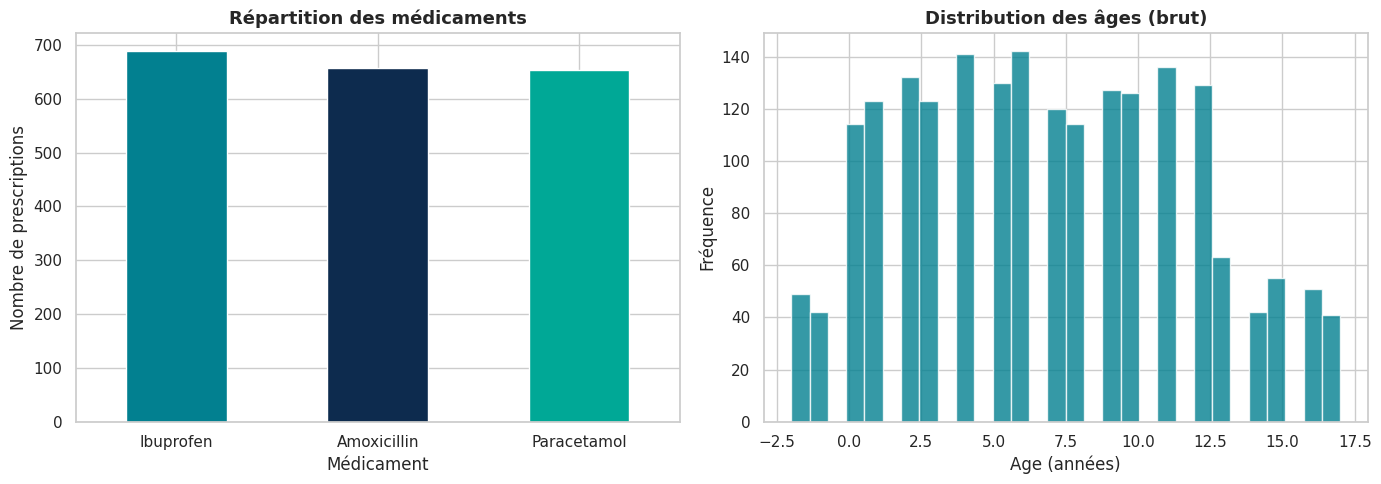

In [5]:
print('Distribution des médicaments:')
print(df['medication_name'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Répartition médicaments
df['medication_name'].value_counts().plot(kind='bar', ax=axes[0], color=['#028090', '#0D2B4E', '#00A896'])
axes[0].set_title('Répartition des médicaments', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Médicament')
axes[0].set_ylabel('Nombre de prescriptions')
axes[0].tick_params(axis='x', rotation=0)

# Distribution des âges
axes[1].hist(df['age_years'], bins=30, color='#028090', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution des âges (brut)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age (années)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

### 2.3 Détection des anomalies (BO — Business Overview)

In [6]:
print('=== RAPPORT D\'ANOMALIES (BO) ===')
print(f"\n📌 Valeurs manquantes par colonne:")
print(df.isnull().sum())
print(f"\n  → Taux de valeurs manquantes (frequency_per_day): {df['frequency_per_day'].isnull().mean()*100:.2f}%")

print(f"\n⚠️  Ages négatifs       : {(df['age_years'] < 0).sum()} lignes")
print(f"⚠️  Poids négatifs      : {(df['weight_kg'] < 0).sum()} lignes")
print(f"⚠️  Fréquences < 0      : {(df['frequency_per_day'] < 0).sum()} lignes")
print(f"⚠️  Fréquences = 0      : {(df['frequency_per_day'] == 0).sum()} lignes")

print(f"\n📊 Range age_years     : [{df['age_years'].min()}, {df['age_years'].max()}]")
print(f"📊 Range weight_kg     : [{df['weight_kg'].min():.2f}, {df['weight_kg'].max():.2f}]")
print(f"📊 Range frequency     : [{df['frequency_per_day'].min()}, {df['frequency_per_day'].max()}]")

=== RAPPORT D'ANOMALIES (BO) ===

📌 Valeurs manquantes par colonne:
patient_id               0
age_years                0
weight_kg                0
medication_name          0
prescribed_dose_mg       0
recommended_dose_mg      0
frequency_per_day      327
dtype: int64

  → Taux de valeurs manquantes (frequency_per_day): 16.35%

⚠️  Ages négatifs       : 91 lignes
⚠️  Poids négatifs      : 176 lignes
⚠️  Fréquences < 0      : 289 lignes
⚠️  Fréquences = 0      : 236 lignes

📊 Range age_years     : [-2, 17]
📊 Range weight_kg     : [-9.98, 49.99]
📊 Range frequency     : [-1.0, 10.0]


## 🧹 3. Nettoyage des Données (DSO — Data Scrubbing Operations)

Sur la base des anomalies identifiées à l'étape BO, nous appliquons les corrections nécessaires.

### 3.1 Copie de sécurité du dataset brut

In [7]:
df_raw = df.copy()
df_clean = df.copy()
print(f'✅ Copie de sécurité créée : df_raw ({df_raw.shape[0]} lignes)')

✅ Copie de sécurité créée : df_raw (2000 lignes)


### 3.2 Suppression des doublons

In [8]:
n_before = len(df_clean)
print(f'Doublons détectés : {df_clean.duplicated().sum()}')
df_clean.drop_duplicates(inplace=True)
print(f'Doublons après suppression : {df_clean.duplicated().sum()}')
print(f'Lignes supprimées : {n_before - len(df_clean)}')

Doublons détectés : 0
Doublons après suppression : 0
Lignes supprimées : 0


### 3.3 Correction des valeurs aberrantes physiologiques

In [9]:
# Ages négatifs → valeur absolue (hypothèse : erreur de saisie)
n_neg_age = (df_clean['age_years'] < 0).sum()
df_clean['age_years'] = df_clean['age_years'].abs()
print(f'✅ Ages négatifs corrigés : {n_neg_age} → valeur absolue appliquée')
print(f'   Vérification : {(df_clean["age_years"] < 0).sum()} ages négatifs restants')

# Poids négatifs → valeur absolue
n_neg_weight = (df_clean['weight_kg'] < 0).sum()
df_clean['weight_kg'] = df_clean['weight_kg'].abs()
print(f'\n✅ Poids négatifs corrigés : {n_neg_weight} → valeur absolue appliquée')
print(f'   Vérification : {(df_clean["weight_kg"] < 0).sum()} poids négatifs restants')

# Ages > 17 (pédiatrique = 0–17 ans) → suppression
n_adult = (df_clean['age_years'] > 17).sum()
df_clean = df_clean[df_clean['age_years'] <= 17]
print(f'\n✅ Patients adultes (> 17 ans) supprimés : {n_adult} lignes')

✅ Ages négatifs corrigés : 91 → valeur absolue appliquée
   Vérification : 0 ages négatifs restants

✅ Poids négatifs corrigés : 176 → valeur absolue appliquée
   Vérification : 0 poids négatifs restants

✅ Patients adultes (> 17 ans) supprimés : 0 lignes


### 3.4 Correction des fréquences invalides

In [10]:
# Fréquences négatives → valeur absolue
n_neg_freq = (df_clean['frequency_per_day'] < 0).sum()
df_clean['frequency_per_day'] = df_clean['frequency_per_day'].abs()
print(f'✅ Fréquences négatives corrigées : {n_neg_freq} → valeur absolue')

# Fréquences = 0 → on les garde mais on flag (cas particuliers ex : dose unique)
n_zero_freq = (df_clean['frequency_per_day'] == 0).sum()
print(f'ℹ️  Fréquences = 0 conservées : {n_zero_freq} (dose unique possible)')

✅ Fréquences négatives corrigées : 289 → valeur absolue
ℹ️  Fréquences = 0 conservées : 236 (dose unique possible)


### 3.5 Gestion des valeurs manquantes

In [11]:
print('Valeurs manquantes avant imputation:')
print(df_clean.isnull().sum())

# Imputation par médiane groupée par médicament (plus cohérent cliniquement)
df_clean['frequency_per_day'] = df_clean.groupby('medication_name')['frequency_per_day'].transform(
    lambda x: x.fillna(x.median())
)

print('\nValeurs manquantes après imputation par médiane groupée :')
print(df_clean.isnull().sum())
print('\n✅ Imputation terminée')

Valeurs manquantes avant imputation:
patient_id               0
age_years                0
weight_kg                0
medication_name          0
prescribed_dose_mg       0
recommended_dose_mg      0
frequency_per_day      327
dtype: int64

Valeurs manquantes après imputation par médiane groupée :
patient_id             0
age_years              0
weight_kg              0
medication_name        0
prescribed_dose_mg     0
recommended_dose_mg    0
frequency_per_day      0
dtype: int64

✅ Imputation terminée


## ⚙️ 4. Transformation des Données & Feature Engineering

### 4.1 Création de la variable cible : `dose_status`

In [12]:
# Calcul du ratio dose prescrite / dose recommandée
df_clean['dose_ratio'] = df_clean['prescribed_dose_mg'] / df_clean['recommended_dose_mg']

# Classification selon le ratio
def classify_dose(ratio):
    if ratio < 0.8:
        return 'underdose'
    elif ratio > 1.2:
        return 'overdose'
    else:
        return 'normal'

df_clean['dose_status'] = df_clean['dose_ratio'].apply(classify_dose)

print('Distribution de la variable cible dose_status :')
print(df_clean['dose_status'].value_counts())
print(f"\nPourcentages:")
print(df_clean['dose_status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Distribution de la variable cible dose_status :
dose_status
underdose    988
normal       516
overdose     496
Name: count, dtype: int64

Pourcentages:
dose_status
underdose    49.4%
normal       25.8%
overdose     24.8%
Name: proportion, dtype: str


### 4.2 Création de variables dérivées

In [13]:
# Dose normalisée par le poids corporel (dose mg/kg)
df_clean['dose_mg_per_kg'] = df_clean['prescribed_dose_mg'] / df_clean['weight_kg']

# Groupe d'âge pédiatrique
def age_group(age):
    if age <= 1:
        return 'nourrisson'
    elif age <= 5:
        return 'petite_enfance'
    elif age <= 12:
        return 'enfant'
    else:
        return 'adolescent'

df_clean['age_group'] = df_clean['age_years'].apply(age_group)

print('Nouvelles variables créées :')
print(' - dose_mg_per_kg (dose normalisée par poids)')
print(' - age_group (catégorie pédiatrique)')
print('\nDistribution age_group :')
print(df_clean['age_group'].value_counts())

Nouvelles variables créées :
 - dose_mg_per_kg (dose normalisée par poids)
 - age_group (catégorie pédiatrique)

Distribution age_group :
age_group
enfant            894
petite_enfance    575
nourrisson        279
adolescent        252
Name: count, dtype: int64


### 4.3 Encodage des variables catégorielles

In [14]:
label_encoders = {}

# Encodage medication_name
le_med = LabelEncoder()
df_clean['medication_name_enc'] = le_med.fit_transform(df_clean['medication_name'])
label_encoders['medication_name'] = le_med
print('Encodage medication_name :')
for i, cls in enumerate(le_med.classes_):
    print(f'  {cls} → {i}')

# Encodage age_group
le_age = LabelEncoder()
df_clean['age_group_enc'] = le_age.fit_transform(df_clean['age_group'])
label_encoders['age_group'] = le_age
print('\nEncodage age_group :')
for i, cls in enumerate(le_age.classes_):
    print(f'  {cls} → {i}')

# Encodage variable cible dose_status
le_target = LabelEncoder()
df_clean['dose_status_enc'] = le_target.fit_transform(df_clean['dose_status'])
label_encoders['dose_status'] = le_target
print('\nEncodage dose_status (cible) :')
for i, cls in enumerate(le_target.classes_):
    print(f'  {cls} → {i}')

Encodage medication_name :
  Amoxicillin → 0
  Ibuprofen → 1
  Paracetamol → 2

Encodage age_group :
  adolescent → 0
  enfant → 1
  nourrisson → 2
  petite_enfance → 3

Encodage dose_status (cible) :
  normal → 0
  overdose → 1
  underdose → 2


### 4.4 Normalisation (StandardScaler)

In [15]:
features_to_normalize = ['age_years', 'weight_kg', 'prescribed_dose_mg', 
                          'recommended_dose_mg', 'frequency_per_day', 
                          'dose_ratio', 'dose_mg_per_kg']

scaler = StandardScaler()
df_normalized = df_clean.copy()
df_normalized[features_to_normalize] = scaler.fit_transform(df_clean[features_to_normalize])

print('✅ Normalisation StandardScaler appliquée sur :')
for f in features_to_normalize:
    print(f'   - {f}')

print('\nVérification (mean ≈ 0, std ≈ 1) :')
print(df_normalized[features_to_normalize].describe().loc[['mean', 'std']].round(3))

✅ Normalisation StandardScaler appliquée sur :


   - age_years
   - weight_kg
   - prescribed_dose_mg
   - recommended_dose_mg
   - frequency_per_day
   - dose_ratio
   - dose_mg_per_kg

Vérification (mean ≈ 0, std ≈ 1) :


      age_years  weight_kg  prescribed_dose_mg  recommended_dose_mg  \
mean       -0.0       -0.0                -0.0                  0.0   
std         1.0        1.0                 1.0                  1.0   

      frequency_per_day  dose_ratio  dose_mg_per_kg  
mean                0.0         0.0            -0.0  
std                 1.0         1.0             1.0  


## 📊 5. Sélection des Caractéristiques

### 5.1 Matrice de corrélation

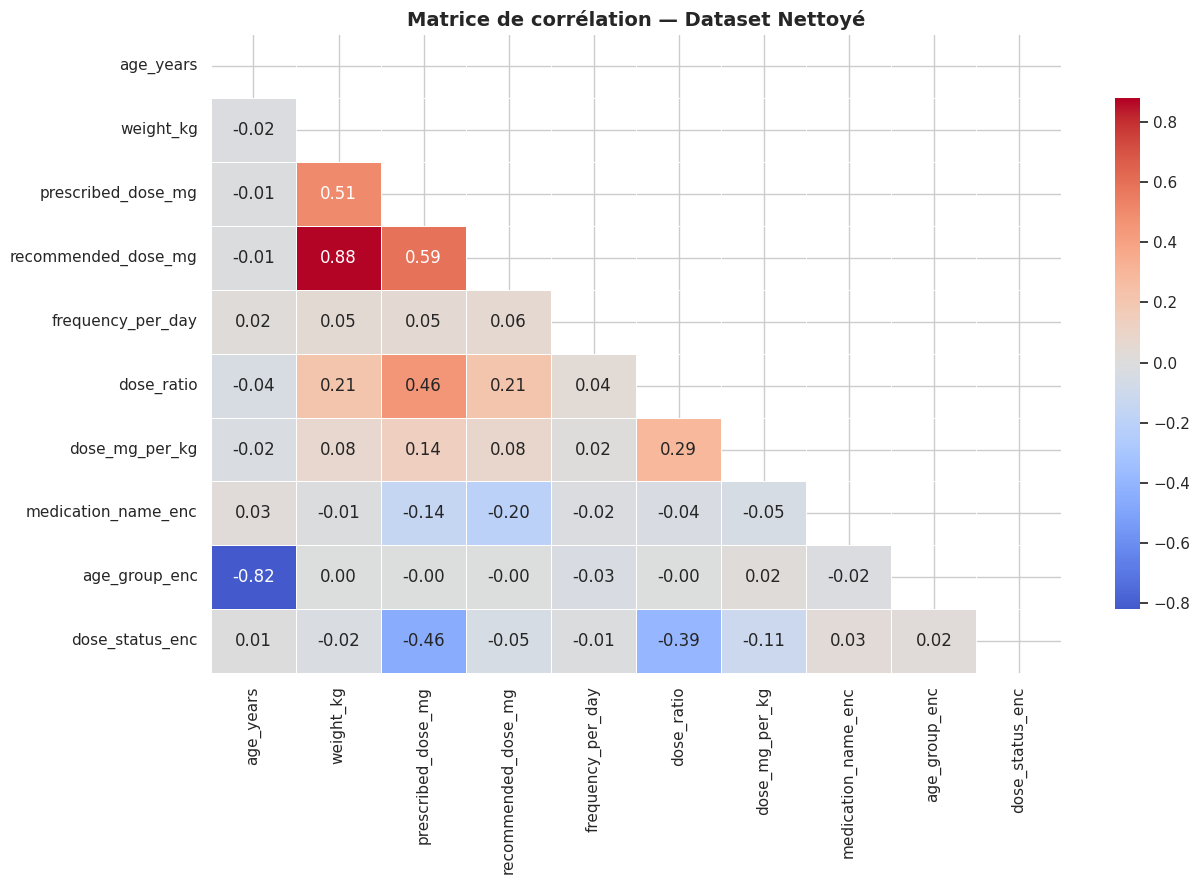

In [16]:
numeric_cols = df_normalized.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_normalized[numeric_cols].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            mask=mask, center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation — Dataset Nettoyé', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Corrélations avec la variable cible

Corrélations absolues avec dose_status_enc :
dose_status_enc        1.000000
prescribed_dose_mg     0.458174
dose_ratio             0.392385
dose_mg_per_kg         0.110917
recommended_dose_mg    0.046600
medication_name_enc    0.033250
weight_kg              0.024517
age_group_enc          0.023891
age_years              0.008277
frequency_per_day      0.005918
Name: dose_status_enc, dtype: float64

✅ Caractéristiques sélectionnées (|corr| > 0.1) :
['prescribed_dose_mg', 'dose_ratio', 'dose_mg_per_kg']


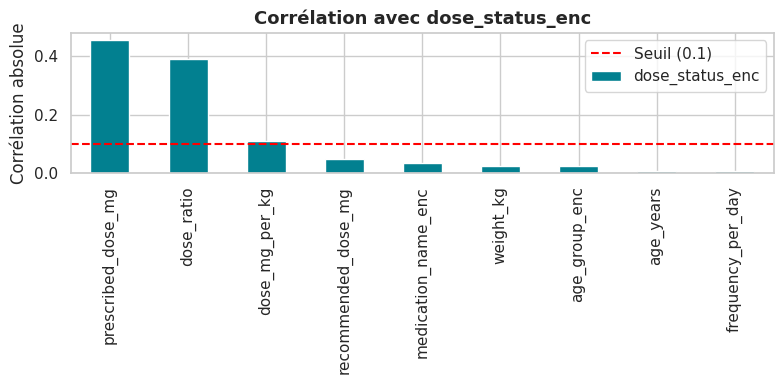

In [17]:
target = 'dose_status_enc'
correlation_threshold = 0.1

target_corr = corr_matrix[target].abs().sort_values(ascending=False)
print(f'Corrélations absolues avec {target} :')
print(target_corr)

selected_features = target_corr[target_corr > correlation_threshold].index.tolist()
if target in selected_features:
    selected_features.remove(target)

print(f'\n✅ Caractéristiques sélectionnées (|corr| > {correlation_threshold}) :')
print(selected_features)

# Visualisation
plt.figure(figsize=(8, 4))
target_corr.drop(target).head(10).plot(kind='bar', color='#028090', edgecolor='white')
plt.axhline(y=correlation_threshold, color='red', linestyle='--', label=f'Seuil ({correlation_threshold})')
plt.title(f'Corrélation avec {target}', fontsize=13, fontweight='bold')
plt.ylabel('Corrélation absolue')
plt.legend()
plt.tight_layout()
plt.show()

## 🔭 6. Analyse en Composantes Principales (ACP / PCA)

L'ACP permet de **réduire la dimensionnalité** du dataset tout en conservant un maximum de variance. Elle facilite la **visualisation** des données et aide à comprendre la structure des classes (`normal`, `underdose`, `overdose`).

### 6.1 Application de la PCA

In [18]:
from sklearn.decomposition import PCA

# Utiliser les features numériques normalisées (sans la cible)
features_pca = ['age_years', 'weight_kg', 'prescribed_dose_mg',
                 'recommended_dose_mg', 'frequency_per_day',
                 'dose_ratio', 'dose_mg_per_kg']

X_pca = df_normalized[features_pca].dropna()
y_pca = df_normalized.loc[X_pca.index, 'dose_status']

# ACP complète pour analyser la variance expliquée
pca_full = PCA()
pca_full.fit(X_pca)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print('=== Variance expliquée par composante ===')
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    print(f'  PC{i+1} : {ev*100:.2f}%  (cumulé : {cv*100:.2f}%)')

n_components_95 = (cumulative_var < 0.95).sum() + 1
print(f'\n✅ Composantes nécessaires pour 95% de variance : {n_components_95}')

=== Variance expliquée par composante ===
  PC1 : 36.38%  (cumulé : 36.38%)
  PC2 : 16.95%  (cumulé : 53.34%)
  PC3 : 14.55%  (cumulé : 67.89%)
  PC4 : 13.85%  (cumulé : 81.73%)
  PC5 : 10.69%  (cumulé : 92.43%)
  PC6 : 5.97%  (cumulé : 98.40%)
  PC7 : 1.60%  (cumulé : 100.00%)

✅ Composantes nécessaires pour 95% de variance : 6


### 6.2 Courbe de variance expliquée (Scree Plot)

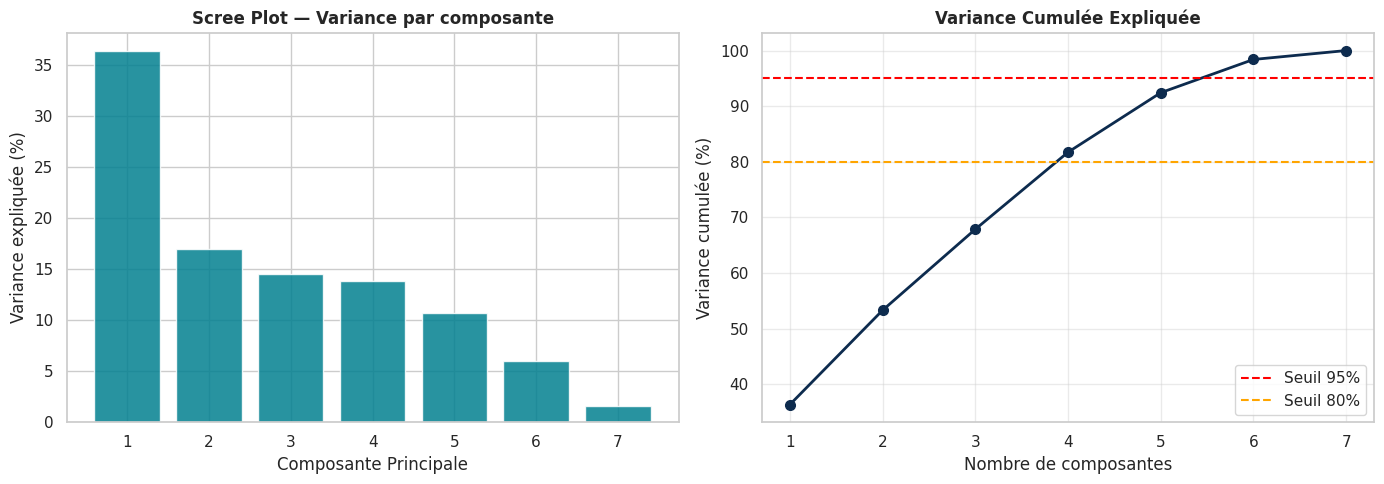

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance par composante
axes[0].bar(range(1, len(explained_var)+1), explained_var * 100,
            color='#028090', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Composante Principale')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Scree Plot — Variance par composante', fontweight='bold')
axes[0].set_xticks(range(1, len(explained_var)+1))

# Variance cumulée
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100,
             marker='o', color='#0D2B4E', linewidth=2, markersize=7)
axes[1].axhline(y=95, color='red', linestyle='--', label='Seuil 95%')
axes[1].axhline(y=80, color='orange', linestyle='--', label='Seuil 80%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance Cumulée Expliquée', fontweight='bold')
axes[1].set_xticks(range(1, len(cumulative_var)+1))
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### 6.3 Projection 2D — PC1 vs PC2

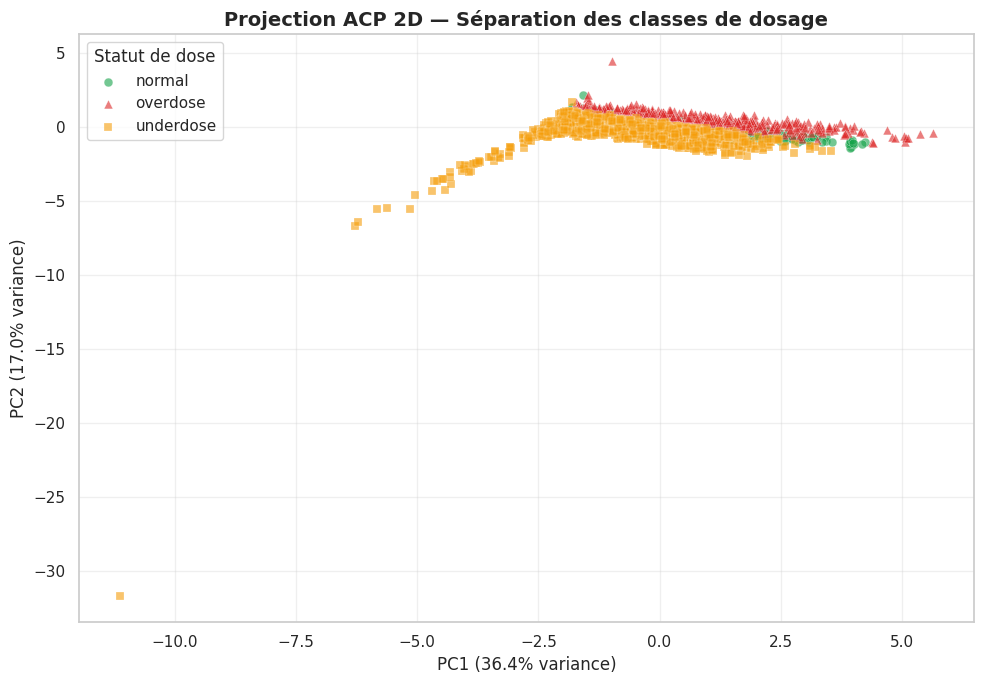

PC1 explique 36.4% de la variance
PC2 explique 17.0% de la variance
Total 2 composantes : 53.3%


In [20]:
# PCA réduite à 2 composantes pour la visualisation
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_pca)

df_pca_2d = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
df_pca_2d['dose_status'] = y_pca.values

colors_pca = {'normal': '#16A34A', 'underdose': '#F59E0B', 'overdose': '#DC2626'}
markers_pca = {'normal': 'o', 'underdose': 's', 'overdose': '^'}

plt.figure(figsize=(10, 7))
for status, group in df_pca_2d.groupby('dose_status'):
    plt.scatter(group['PC1'], group['PC2'],
                c=colors_pca[status], marker=markers_pca[status],
                label=status, alpha=0.6, s=40, edgecolors='white', linewidths=0.3)

plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)', fontsize=12)
plt.title('Projection ACP 2D — Séparation des classes de dosage', fontsize=14, fontweight='bold')
plt.legend(title='Statut de dose', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'PC1 explique {explained_var[0]*100:.1f}% de la variance')
print(f'PC2 explique {explained_var[1]*100:.1f}% de la variance')
print(f'Total 2 composantes : {(explained_var[0]+explained_var[1])*100:.1f}%')

### 6.4 Contribution des variables (Loadings)

=== Contributions des variables aux composantes ===
                       PC1    PC2
age_years           -0.024 -0.165
weight_kg            0.539 -0.313
prescribed_dose_mg   0.506  0.072
recommended_dose_mg  0.557 -0.306
frequency_per_day    0.064 -0.006
dose_ratio           0.334  0.558
dose_mg_per_kg       0.165  0.681


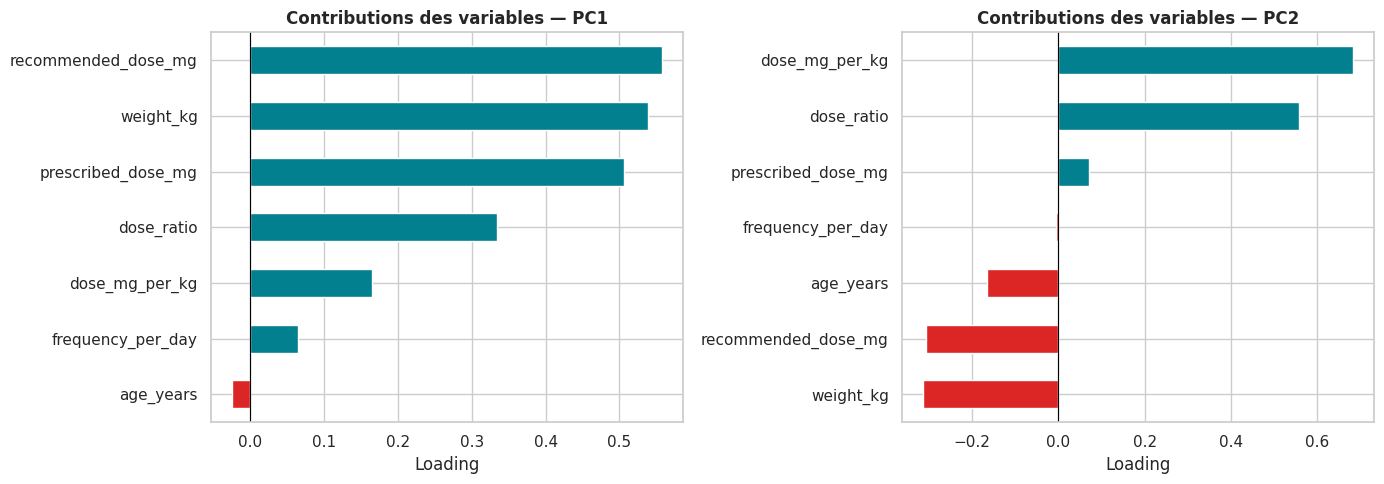

In [21]:
# Matrice des loadings
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=features_pca,
    columns=['PC1', 'PC2']
)

print('=== Contributions des variables aux composantes ===')
print(loadings.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pc in zip(axes, ['PC1', 'PC2']):
    loadings[pc].sort_values().plot(
        kind='barh', ax=ax,
        color=['#DC2626' if v < 0 else '#028090' for v in loadings[pc].sort_values()],
        edgecolor='white'
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Contributions des variables — {pc}', fontweight='bold')
    ax.set_xlabel('Loading')

plt.tight_layout()
plt.show()

### 6.5 Projection 3D — PC1, PC2, PC3

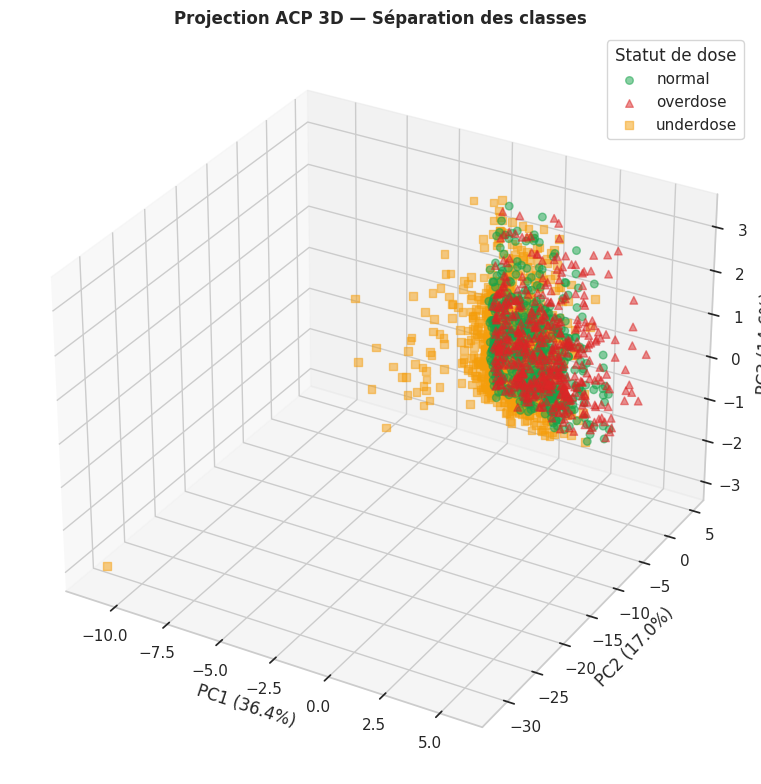


✅ 3 composantes capturent 67.9% de la variance totale


In [22]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_pca)

df_pca_3d = pd.DataFrame(X_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['dose_status'] = y_pca.values

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

for status, group in df_pca_3d.groupby('dose_status'):
    ax.scatter(group['PC1'], group['PC2'], group['PC3'],
               c=colors_pca[status], marker=markers_pca[status],
               label=status, alpha=0.5, s=30)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('Projection ACP 3D — Séparation des classes', fontweight='bold')
ax.legend(title='Statut de dose')

plt.tight_layout()
plt.show()

total_3d = sum(pca_3d.explained_variance_ratio_)*100
print(f'\n✅ 3 composantes capturent {total_3d:.1f}% de la variance totale')

## 📈 7. Visualisation & Validation du Dataset Final

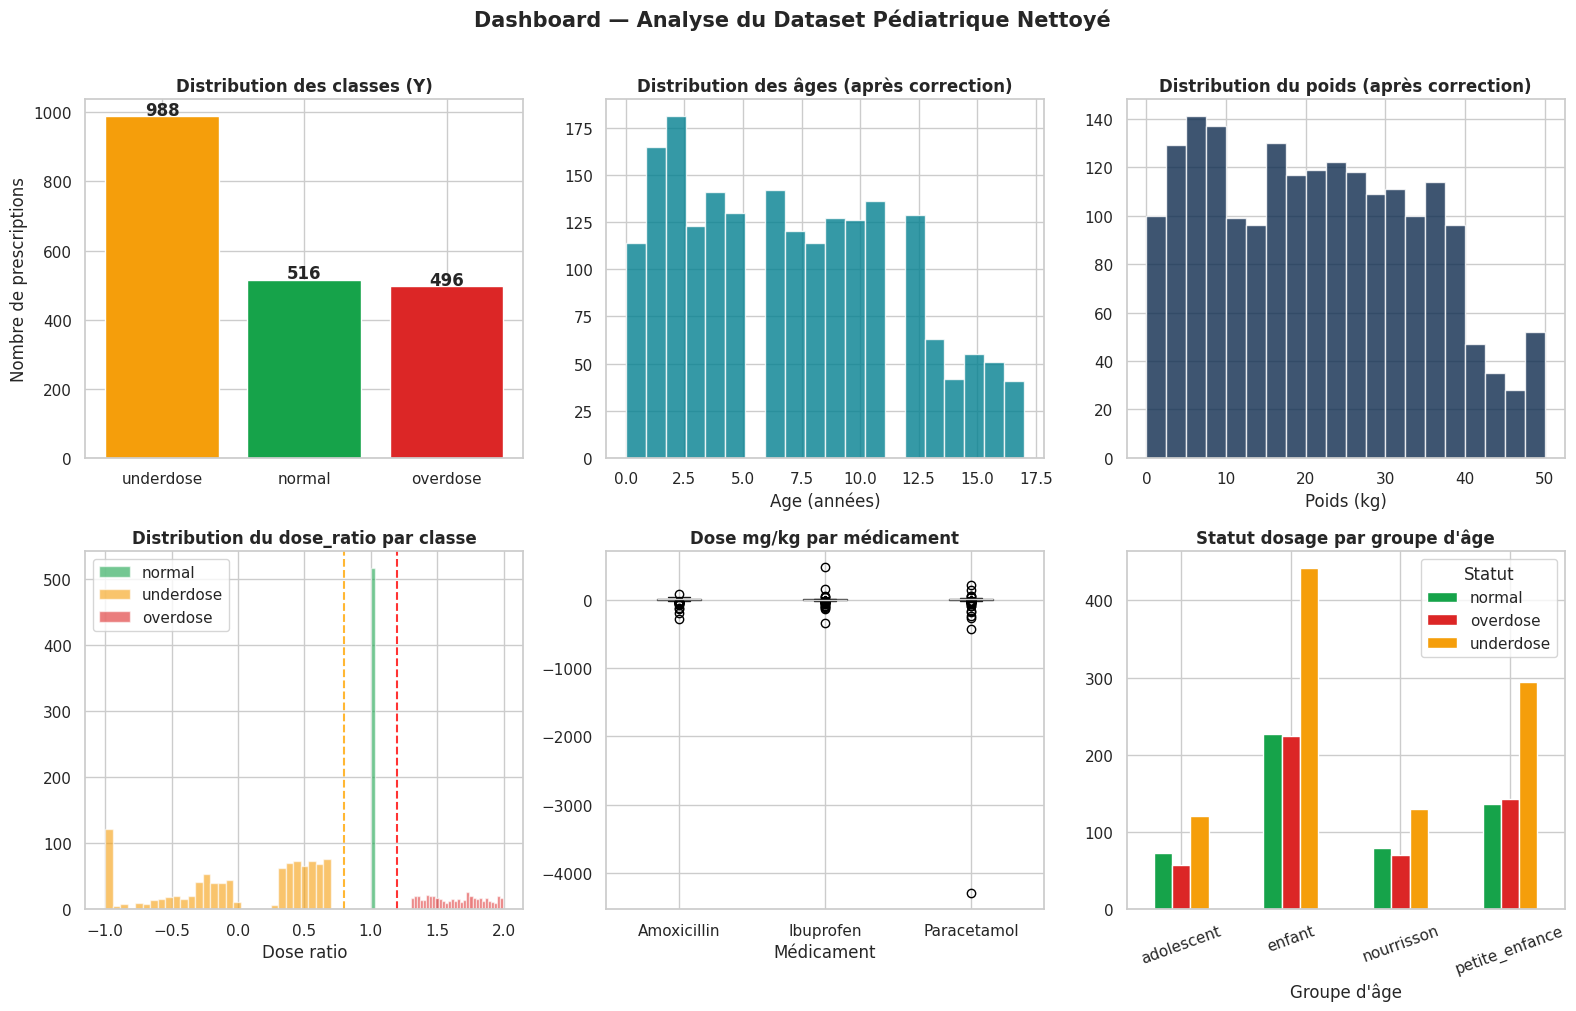

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

colors = {'normal': '#16A34A', 'underdose': '#F59E0B', 'overdose': '#DC2626'}

# 1. Distribution des classes
counts = df_clean['dose_status'].value_counts()
bars = axes[0,0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
axes[0,0].set_title('Distribution des classes (Y)', fontweight='bold')
axes[0,0].set_ylabel('Nombre de prescriptions')
for bar, val in zip(bars, counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontweight='bold')

# 2. Distribution âge après correction
axes[0,1].hist(df_clean['age_years'], bins=20, color='#028090', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Distribution des âges (après correction)', fontweight='bold')
axes[0,1].set_xlabel('Age (années)')

# 3. Distribution poids après correction
axes[0,2].hist(df_clean['weight_kg'], bins=20, color='#0D2B4E', edgecolor='white', alpha=0.8)
axes[0,2].set_title('Distribution du poids (après correction)', fontweight='bold')
axes[0,2].set_xlabel('Poids (kg)')

# 4. Dose ratio par classe
for status, color in colors.items():
    subset = df_clean[df_clean['dose_status'] == status]['dose_ratio']
    axes[1,0].hist(subset.clip(-1, 3), bins=30, alpha=0.6, label=status, color=color)
axes[1,0].set_title('Distribution du dose_ratio par classe', fontweight='bold')
axes[1,0].set_xlabel('Dose ratio')
axes[1,0].legend()
axes[1,0].axvline(x=0.8, color='orange', linestyle='--', alpha=0.8)
axes[1,0].axvline(x=1.2, color='red', linestyle='--', alpha=0.8)

# 5. Boxplot dose_mg_per_kg par médicament
df_clean.boxplot(column='dose_mg_per_kg', by='medication_name', ax=axes[1,1], 
                  patch_artist=True)
axes[1,1].set_title('Dose mg/kg par médicament', fontweight='bold')
axes[1,1].set_xlabel('Médicament')
plt.sca(axes[1,1])
plt.xticks(rotation=0)

# 6. Groupes d'âge par classe de dosage
pivot = df_clean.groupby(['age_group', 'dose_status']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1,2], color=[colors[c] for c in pivot.columns], edgecolor='white')
axes[1,2].set_title('Statut dosage par groupe d\'âge', fontweight='bold')
axes[1,2].set_xlabel('Groupe d\'âge')
axes[1,2].tick_params(axis='x', rotation=20)
axes[1,2].legend(title='Statut')

plt.suptitle('Dashboard — Analyse du Dataset Pédiatrique Nettoyé', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## ✅ 8. Dataset Final — Récapitulatif & Export

In [24]:
print('='*60)
print('      RAPPORT FINAL — DATA PREPARATION')
print('='*60)

print(f'\n📊 Dimensions finales : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes')
print(f'   (vs {df_raw.shape[0]} lignes au départ)')

print('\n✅ Problèmes traités :')
print(f'   - Doublons supprimés       : OK')
print(f'   - Ages négatifs corrigés   : {(df_raw["age_years"] < 0).sum()} → 0')
print(f'   - Poids négatifs corrigés  : {(df_raw["weight_kg"] < 0).sum()} → 0')
print(f'   - Fréquences invalides     : {(df_raw["frequency_per_day"] < 0).sum()} → 0')
print(f'   - Valeurs manquantes       : {df_raw["frequency_per_day"].isnull().sum()} → {df_clean["frequency_per_day"].isnull().sum()}')

print('\n🔧 Transformations appliquées :')
print('   - LabelEncoder : medication_name, age_group, dose_status')
print('   - StandardScaler : 7 variables numériques')
print('   - Feature Engineering : dose_ratio, dose_status, dose_mg_per_kg, age_group')

print('\n📌 Variable cible (Y) créée :')
for status, count in df_clean['dose_status'].value_counts().items():
    pct = count/len(df_clean)*100
    print(f'   - {status:<12} : {count:>5} prescriptions ({pct:.1f}%)')

print('\n' + '='*60)

      RAPPORT FINAL — DATA PREPARATION

📊 Dimensions finales : 2000 lignes × 14 colonnes
   (vs 2000 lignes au départ)

✅ Problèmes traités :
   - Doublons supprimés       : OK
   - Ages négatifs corrigés   : 91 → 0
   - Poids négatifs corrigés  : 176 → 0
   - Fréquences invalides     : 289 → 0
   - Valeurs manquantes       : 327 → 0

🔧 Transformations appliquées :
   - LabelEncoder : medication_name, age_group, dose_status
   - StandardScaler : 7 variables numériques
   - Feature Engineering : dose_ratio, dose_status, dose_mg_per_kg, age_group

📌 Variable cible (Y) créée :
   - underdose    :   988 prescriptions (49.4%)
   - normal       :   516 prescriptions (25.8%)
   - overdose     :   496 prescriptions (24.8%)



In [25]:
# Export du dataset final propre
df_clean.to_csv('pediatric_dose_cleaned.csv', index=False)
print('✅ Dataset nettoyé exporté → pediatric_dose_cleaned.csv')

# Export du dataset normalisé pour le ML
X_cols = selected_features
y_col = 'dose_status_enc'

df_ml = df_normalized[X_cols + [y_col]].copy()
df_ml.to_csv('pediatric_dose_ml_ready.csv', index=False)
print(f'✅ Dataset ML-ready exporté → pediatric_dose_ml_ready.csv')
print(f'   Colonnes X : {X_cols}')
print(f'   Colonne Y  : {y_col}')

df_clean.head()

✅ Dataset nettoyé exporté → pediatric_dose_cleaned.csv
✅ Dataset ML-ready exporté → pediatric_dose_ml_ready.csv
   Colonnes X : ['prescribed_dose_mg', 'dose_ratio', 'dose_mg_per_kg']
   Colonne Y  : dose_status_enc


,patient_id,age_years,weight_kg,medication_name,prescribed_dose_mg,recommended_dose_mg,frequency_per_day,dose_ratio,dose_status,dose_mg_per_kg,age_group,medication_name_enc,age_group_enc,dose_status_enc
0,P1,0,4.69,Amoxicillin,93.87,93.87,2.0,1.000000,normal,20.014925,nourrisson,0,2,0
1,P2,0,20.32,Amoxicillin,683.39,406.43,10.0,1.681446,overdose,33.631398,nourrisson,0,2,1
2,P3,2,31.89,Paracetamol,478.33,478.33,0.0,1.000000,normal,14.999373,petite_enfance,2,3,0
3,P4,9,38.43,Ibuprofen,578.42,384.28,2.0,1.505205,overdose,15.051262,enfant,1,1,1
4,P5,4,11.43,Paracetamol,-82.22,171.48,3.0,-0.479473,underdose,-7.193351,petite_enfance,2,3,2


---
# 🤖 PARTIE A — Classification Supervisée

**Objectif** : Prédire automatiquement si une prescription est `normal`, `underdose` ou `overdose`.

**Modèles testés** :
- 🌲 Random Forest *(modèle principal recommandé)*
- 🔵 SVM — Support Vector Machine
- ⚡ XGBoost — Extreme Gradient Boosting
- 🚀 LightGBM *(bonus)*
- 📍 KNN *(bonus)*


## 📦 A.1 Imports & Préparation des données

In [26]:
# Installation des librairies nécessaires
import subprocess, sys

libs = ['xgboost', 'lightgbm']
for lib in libs:
    try:
        __import__(lib)
        print(f'✅ {lib} déjà installé')
    except ImportError:
        print(f'📦 Installation de {lib}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])
        print(f'✅ {lib} installé avec succès')


✅ xgboost déjà installé


✅ lightgbm déjà installé


In [27]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              f1_score, roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings; warnings.filterwarnings('ignore')

X = df_normalized[selected_features].copy()
y = df_normalized['dose_status_enc']
class_names = label_encoders['dose_status'].classes_
n_classes   = len(class_names)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'✅ Train : {len(X_train)} | Test : {len(X_test)}')
print(f'   Classes : {list(class_names)}')
print(f'   Features : {selected_features}')

# Palette et fonction d\'évaluation commune
palette_models = {
    'Random Forest' : '#1D9E75',
    'SVM'           : '#028090',
    'XGBoost'       : '#F59E0B',
    'LightGBM'      : '#7C3AED',
    'KNN'           : '#DC2626',
}

def evaluate_model(name, model, y_pred, cv_scores):
    """Affiche rapport + matrice de confusion + importance features si dispo"""
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    print(f'=== {name} ===')
    print(f'Accuracy     : {acc*100:.2f}%')
    print(f'F1 macro     : {f1*100:.2f}%')
    print(f'CV 5-Fold    : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
    print()
    print(classification_report(y_test, y_pred, target_names=class_names))

    has_importance = hasattr(model, 'feature_importances_')
    ncols = 2 if has_importance else 1
    fig, axes = plt.subplots(1, ncols, figsize=(13 if has_importance else 6, 5))
    if ncols == 1: axes = [axes]

    color = palette_models.get(name, '#028090')
    cmap_name = 'Greens' if name=='Random Forest' else ('Blues' if name=='SVM' else ('YlOrBr' if name=='XGBoost' else ('Purples' if name=='LightGBM' else 'Reds')))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
        display_labels=class_names).plot(ax=axes[0], cmap=cmap_name, colorbar=False)
    axes[0].set_title(f'Matrice de Confusion — {name}', fontweight='bold')

    if has_importance:
        imp = pd.Series(model.feature_importances_, index=selected_features).sort_values()
        imp.plot(kind='barh', ax=axes[1], color=color, edgecolor='white')
        axes[1].set_title(f'Importance des variables — {name}', fontweight='bold')
        axes[1].set_xlabel('Importance')

    plt.tight_layout(); plt.show()
    return {'Modèle': name, 'Accuracy (%)': round(acc*100,2),
            'F1 macro (%)': round(f1*100,2), 'CV moyen (%)': round(cv_scores.mean()*100,2),
            'CV std': round(cv_scores.std()*100,2)}


✅ Train : 1600 | Test : 400
   Classes : ['normal', 'overdose', 'underdose']
   Features : ['prescribed_dose_mg', 'dose_ratio', 'dose_mg_per_kg']


---
## 🌲 A.2 Random Forest

**Principe** : Ensemble de plusieurs arbres de décision entraînés sur des sous-échantillons aléatoires. Réduit le sur-apprentissage par agrégation (bagging). Robuste au bruit et aux données déséquilibrées.

**Avantages pour ce dataset** : gère bien les 3 médicaments différents, robuste aux valeurs aberrantes résiduelles.


=== Random Forest ===
Accuracy     : 100.00%
F1 macro     : 100.00%
CV 5-Fold    : 100.00% ± 0.00%

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       103
    overdose       1.00      1.00      1.00        99
   underdose       1.00      1.00      1.00       198

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



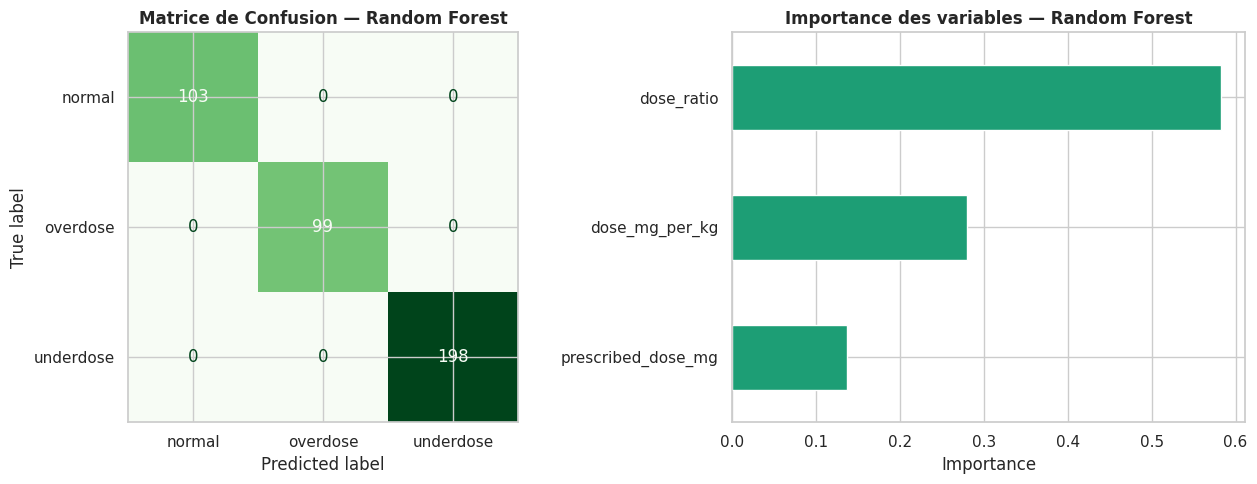

In [28]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=42,
    class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf   = rf.predict(X_test)
scores_rf   = cross_val_score(rf, X, y, cv=cv5, scoring='accuracy')
result_rf   = evaluate_model('Random Forest', rf, y_pred_rf, scores_rf)


---
## 🔵 A.3 SVM (Support Vector Machine)

**Principe** : Trouve l'hyperplan optimal qui maximise la marge entre les classes. Le noyau RBF permet de séparer des classes non linéairement séparables.

**Avantages pour ce dataset** : efficace sur des données normalisées (StandardScaler déjà appliqué), bon comportement avec peu de features.


=== SVM ===
Accuracy     : 99.75%
F1 macro     : 99.75%
CV 5-Fold    : 99.95% ± 0.10%

              precision    recall  f1-score   support

      normal       1.00      0.99      1.00       103
    overdose       1.00      1.00      1.00        99
   underdose       0.99      1.00      1.00       198

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



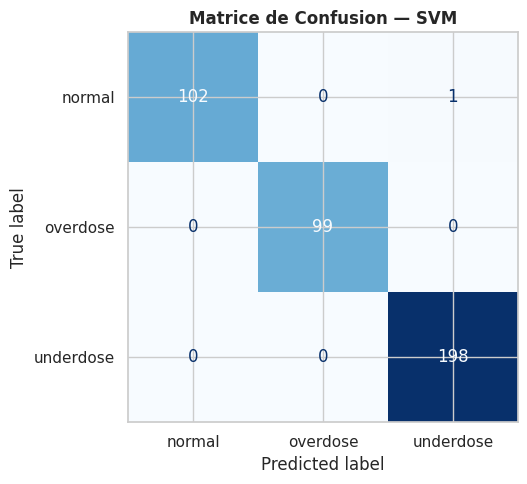

In [29]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale',
          probability=True, class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm  = svm.predict(X_test)
scores_svm  = cross_val_score(svm, X, y, cv=cv5, scoring='accuracy')
result_svm  = evaluate_model('SVM', svm, y_pred_svm, scores_svm)


---
## ⚡ A.4 XGBoost (Extreme Gradient Boosting)

**Principe** : Boosting séquentiel — chaque nouvel arbre corrige les erreurs du précédent. Optimisation par descente de gradient sur la fonction de perte.

**Avantages pour ce dataset** : excellent sur les données tabulaires, gère le déséquilibre via `scale_pos_weight`, très performant en compétitions ML sur des données médicales.


=== XGBoost ===
Accuracy     : 99.75%
F1 macro     : 99.67%
CV 5-Fold    : 99.80% ± 0.29%

              precision    recall  f1-score   support

      normal       0.99      1.00      1.00       103
    overdose       1.00      0.99      0.99        99
   underdose       1.00      1.00      1.00       198

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



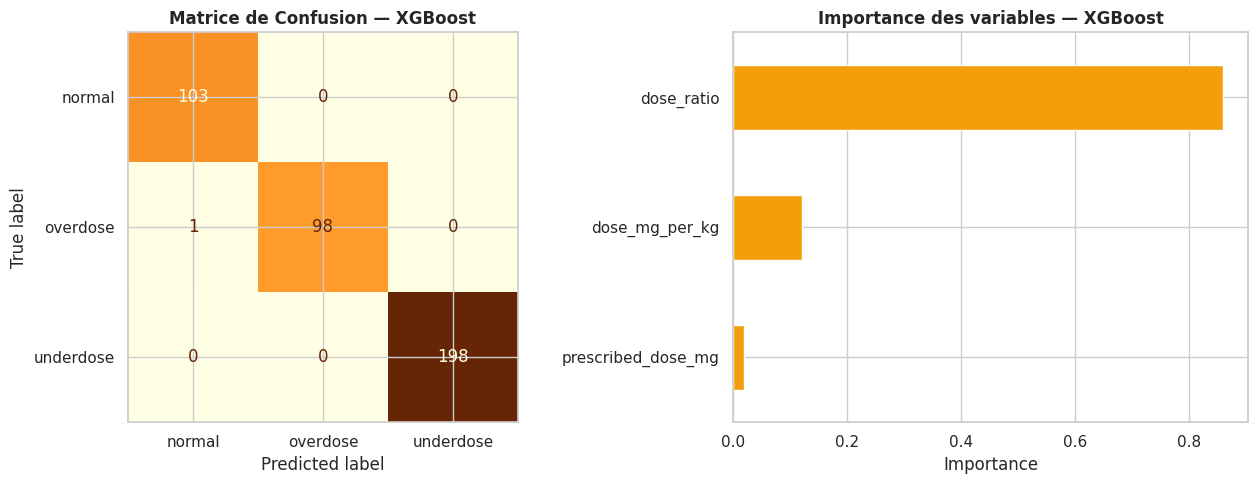

In [30]:
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb  = xgb.predict(X_test)
scores_xgb  = cross_val_score(xgb, X, y, cv=cv5, scoring='accuracy')
result_xgb  = evaluate_model('XGBoost', xgb, y_pred_xgb, scores_xgb)


---
## 🚀 A.5 LightGBM *(bonus)*

**Principe** : Variante de XGBoost plus rapide — construit les arbres feuille par feuille (leaf-wise) plutôt que niveau par niveau. Très efficace sur les grands datasets.

**Avantages** : entraînement plus rapide que XGBoost, gère très bien les features catégorielles encodées.


=== LightGBM ===
Accuracy     : 100.00%
F1 macro     : 100.00%
CV 5-Fold    : 100.00% ± 0.00%

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       103
    overdose       1.00      1.00      1.00        99
   underdose       1.00      1.00      1.00       198

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



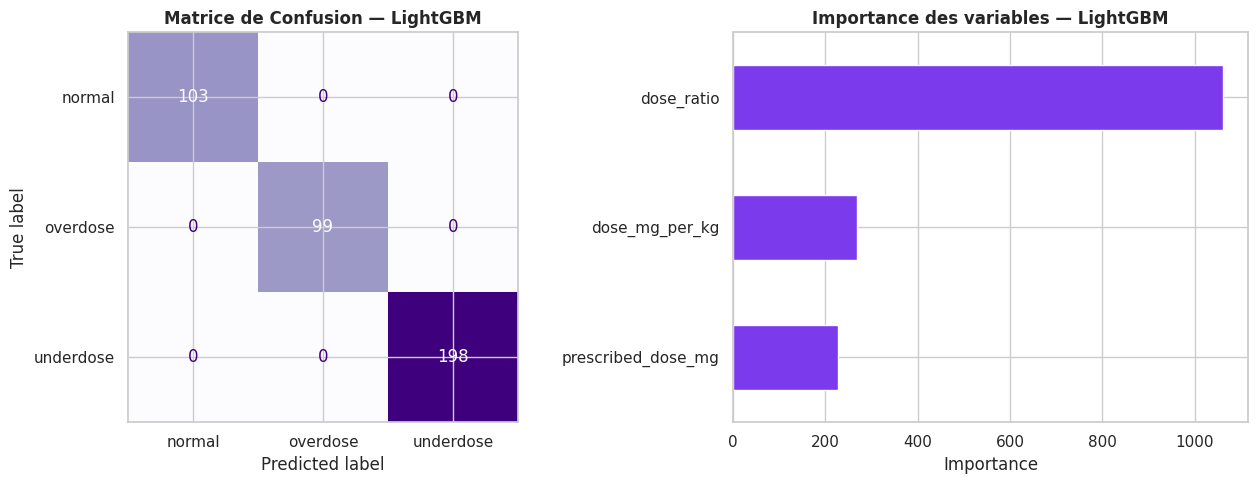

In [31]:
lgbm = LGBMClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=42,
    n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
scores_lgbm = cross_val_score(lgbm, X, y, cv=cv5, scoring='accuracy')
result_lgbm = evaluate_model('LightGBM', lgbm, y_pred_lgbm, scores_lgbm)


---
## 📍 A.6 KNN *(bonus)*

**Principe** : Classifie un point en fonction des k voisins les plus proches dans l'espace des features. Algorithme non paramétrique — pas d'entraînement explicite.

**Avantages** : simple, bon benchmark de référence. Fonctionne bien sur des données normalisées.


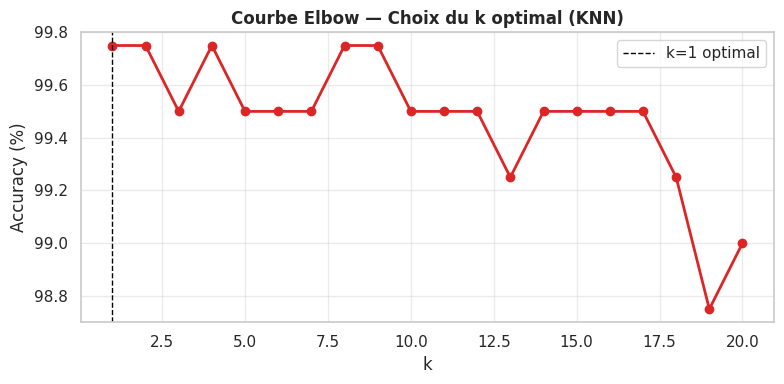

=== KNN ===
Accuracy     : 99.75%
F1 macro     : 99.75%
CV 5-Fold    : 99.90% ± 0.20%

              precision    recall  f1-score   support

      normal       1.00      0.99      1.00       103
    overdose       1.00      1.00      1.00        99
   underdose       0.99      1.00      1.00       198

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



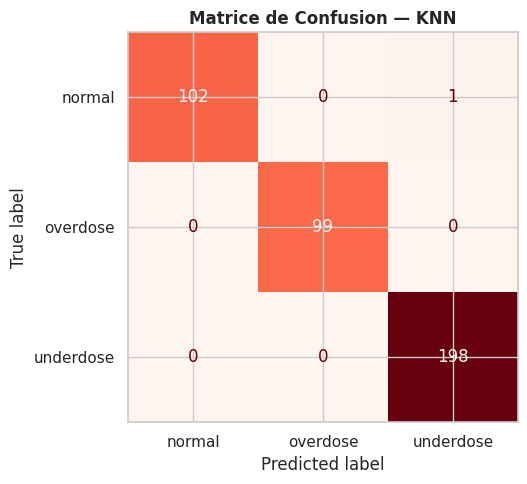

In [32]:
# Elbow : trouver le k optimal
k_accs = [accuracy_score(y_test,
    KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train).predict(X_test))
    for k in range(1, 21)]
best_k = k_accs.index(max(k_accs)) + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1,21), [s*100 for s in k_accs], marker='o', color='#DC2626', lw=2)
ax.axvline(x=best_k, color='black', ls='--', lw=1, label=f'k={best_k} optimal')
ax.set_xlabel('k'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Courbe Elbow — Choix du k optimal (KNN)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred_knn  = knn.predict(X_test)
scores_knn  = cross_val_score(knn, X, y, cv=cv5, scoring='accuracy')
result_knn  = evaluate_model('KNN', knn, y_pred_knn, scores_knn)


---
## ⚙️ A.7 Optimisation des Hyperparamètres (GridSearchCV)

Recherche automatique des meilleurs paramètres pour les **3 modèles principaux** : Random Forest, SVM et XGBoost.


In [33]:
print('--- Optimisation Random Forest ---')
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    {'n_estimators':[100,200], 'max_depth':[6,8,None], 'max_features':['sqrt','log2']},
    cv=cv5, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(f'  Meilleurs params : {grid_rf.best_params_}')
print(f'  F1 macro CV      : {grid_rf.best_score_*100:.2f}%')
print(f'  Accuracy test    : {accuracy_score(y_test, grid_rf.predict(X_test))*100:.2f}%')
print()

print('--- Optimisation SVM ---')
grid_svm = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=42),
    {'C':[0.1,1,10], 'kernel':['rbf','linear'], 'gamma':['scale','auto']},
    cv=cv5, scoring='f1_macro', n_jobs=-1)
grid_svm.fit(X_train, y_train)
print(f'  Meilleurs params : {grid_svm.best_params_}')
print(f'  F1 macro CV      : {grid_svm.best_score_*100:.2f}%')
print(f'  Accuracy test    : {accuracy_score(y_test, grid_svm.predict(X_test))*100:.2f}%')
print()

print('--- Optimisation XGBoost ---')
grid_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, verbosity=0, n_jobs=-1),
    {'n_estimators':[100,200], 'max_depth':[4,5,6], 'learning_rate':[0.05,0.1,0.2]},
    cv=cv5, scoring='f1_macro', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print(f'  Meilleurs params : {grid_xgb.best_params_}')
print(f'  F1 macro CV      : {grid_xgb.best_score_*100:.2f}%')
print(f'  Accuracy test    : {accuracy_score(y_test, grid_xgb.predict(X_test))*100:.2f}%')


--- Optimisation Random Forest ---


  Meilleurs params : {'max_depth': 6, 'max_features': 'sqrt', 'n_estimators': 100}
  F1 macro CV      : 100.00%
  Accuracy test    : 100.00%

--- Optimisation SVM ---


  Meilleurs params : {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
  F1 macro CV      : 100.00%
  Accuracy test    : 100.00%

--- Optimisation XGBoost ---


  Meilleurs params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
  F1 macro CV      : 99.75%
  Accuracy test    : 99.75%


---
## 📈 A.8 Courbes ROC & AUC

Comparaison des **5 modèles** sur leur capacité à discriminer chaque classe. En contexte médical, un **AUC élevé sur overdose** est critique (faux négatif = danger patient).


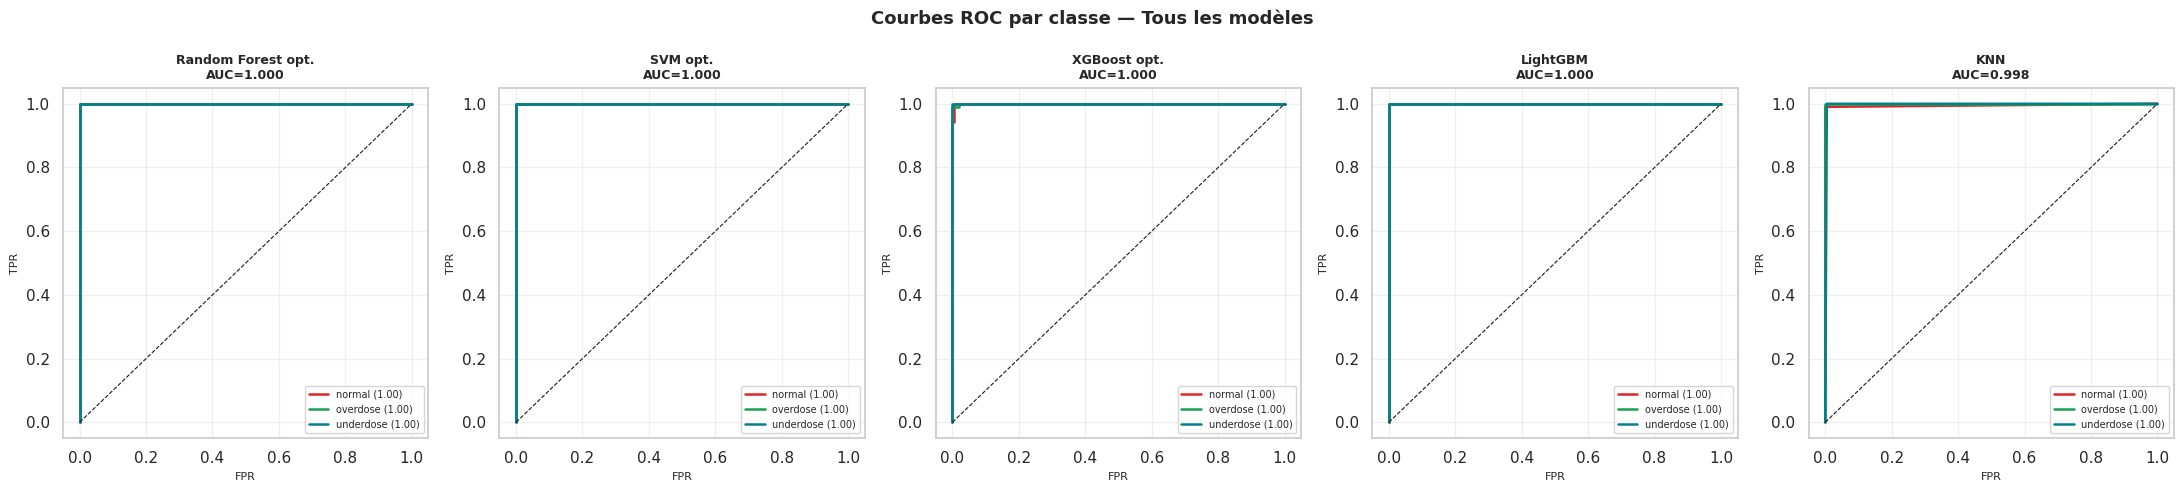

In [34]:
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

optimized_models = {
    'Random Forest opt.' : grid_rf.best_estimator_,
    'SVM opt.'           : grid_svm.best_estimator_,
    'XGBoost opt.'       : grid_xgb.best_estimator_,
    'LightGBM'           : lgbm,
    'KNN'                : knn,
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
roc_summary = []
roc_colors  = ['#1D9E75','#028090','#F59E0B','#7C3AED','#DC2626']
class_colors = ['#DC2626','#16A34A','#028090']

for ax, (mname, model), mc in zip(axes, optimized_models.items(), roc_colors):
    y_score = model.predict_proba(X_test)
    aucs = []
    for i, (cls, cc) in enumerate(zip(class_names, class_colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_score[:,i])
        roc_auc = auc(fpr, tpr); aucs.append(roc_auc)
        ax.plot(fpr, tpr, color=cc, lw=1.8, label=f'{cls} ({roc_auc:.2f})')
    ax.plot([0,1],[0,1],'k--',lw=0.8)
    mean_auc = sum(aucs)/len(aucs)
    roc_summary.append({'Modèle':mname, 'AUC moyen':round(mean_auc,4)})
    ax.set_title(f'{mname}\nAUC={mean_auc:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlabel('FPR',fontsize=8); ax.set_ylabel('TPR',fontsize=8)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Courbes ROC par classe — Tous les modèles', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 📊 A.9 Tableau de Bord Final — Comparaison Complète

=== TABLEAU DE BORD FINAL — CLASSIFICATION SUPERVISÉE ===
              Modèle  Accuracy (%)  F1 macro (%)  AUC macro (%) CV moyen (%)
Random Forest (base)        100.00        100.00         100.00        100.0
Random Forest (opt.)        100.00        100.00         100.00            —
          SVM (base)         99.75         99.75         100.00        99.95
          SVM (opt.)        100.00        100.00         100.00            —
      XGBoost (base)         99.75         99.67         100.00         99.8
            LightGBM        100.00        100.00         100.00        100.0
      XGBoost (opt.)         99.75         99.67          99.99            —
           KNN (k=1)         99.75         99.75          99.76         99.9


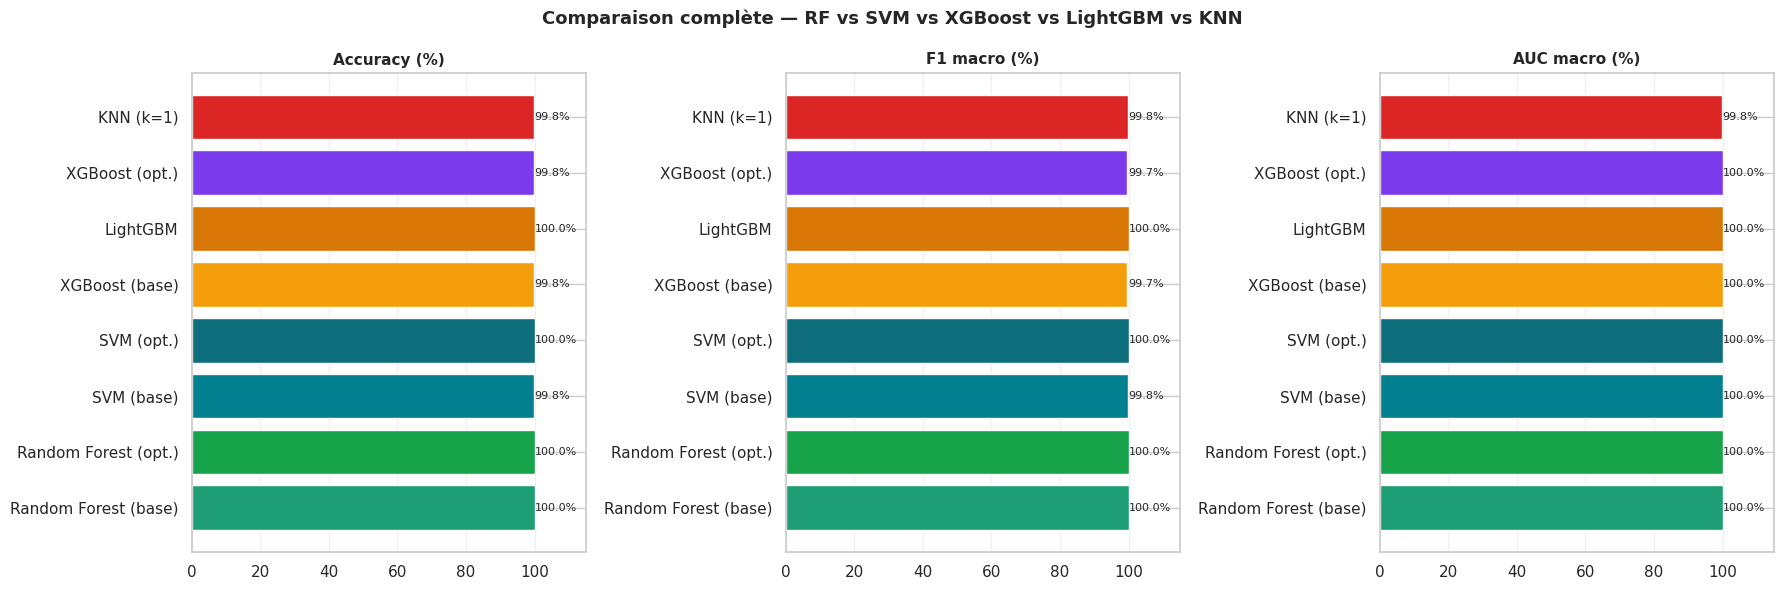

In [35]:
all_models = [
    ('Random Forest (base)',  rf,                      y_pred_rf,   scores_rf),
    ('Random Forest (opt.)',  grid_rf.best_estimator_, grid_rf.best_estimator_.predict(X_test),  None),
    ('SVM (base)',            svm,                     y_pred_svm,  scores_svm),
    ('SVM (opt.)',            grid_svm.best_estimator_,grid_svm.best_estimator_.predict(X_test), None),
    ('XGBoost (base)',        xgb,                     y_pred_xgb,  scores_xgb),
    ('XGBoost (opt.)',        grid_xgb.best_estimator_,grid_xgb.best_estimator_.predict(X_test), None),
    ('LightGBM',              lgbm,                    y_pred_lgbm, scores_lgbm),
    (f'KNN (k={best_k})',     knn,                     y_pred_knn,  scores_knn),
]

rows = []
y_bin = label_binarize(y_test, classes=list(range(n_classes)))
for mname, model, y_pred, cv_sc in all_models:
    proba    = model.predict_proba(X_test)
    auc_m    = roc_auc_score(y_bin, proba, multi_class='ovr', average='macro')*100
    rows.append({
        'Modèle'            : mname,
        'Accuracy (%)'      : round(accuracy_score(y_test, y_pred)*100, 2),
        'F1 macro (%)'      : round(f1_score(y_test, y_pred, average='macro')*100, 2),
        'AUC macro (%)'     : round(auc_m, 2),
        'CV moyen (%)'      : round(cv_sc.mean()*100,2) if cv_sc is not None else '—',
    })

df_results = pd.DataFrame(rows).sort_values('AUC macro (%)', ascending=False).reset_index(drop=True)
print('=== TABLEAU DE BORD FINAL — CLASSIFICATION SUPERVISÉE ===')
print(df_results.to_string(index=False))

# Graphique triple
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_colors = ['#1D9E75','#16A34A','#028090','#0D6E7C','#F59E0B','#D97706','#7C3AED','#DC2626']
for ax, metric in zip(axes, ['Accuracy (%)', 'F1 macro (%)', 'AUC macro (%)']):
    vals = []
    for v in df_results[metric]:
        try: vals.append(float(v))
        except: vals.append(0)
    bars = ax.barh(df_results['Modèle'], vals,
                   color=bar_colors[:len(df_results)], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                f'{bar.get_width():.1f}%', va='center', fontsize=8)
    ax.set_xlim(0,115); ax.set_title(metric, fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Comparaison complète — RF vs SVM vs XGBoost vs LightGBM vs KNN',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 💊 A.10 Prédiction sur Nouvelles Prescriptions

Le **meilleur modèle** (sélectionné automatiquement par AUC) est appliqué sur 3 nouvelles prescriptions.


✅ Meilleur modèle sélectionné : Random Forest (base)



=== PRÉDICTIONS — Random Forest (base) ===
Patient   Médicament       Prescrit  Recommandé   Ratio  Résultat       Confiance
-------------------------------------------------------------------------------------
Patient 1   Amoxicillin          50mg        60mg    0.83  ⚠️ underdose    96.9%
Patient 2   Ibuprofen           300mg       250mg    1.20  🚨overdose     91.3%
Patient 3   Paracetamol         900mg       700mg    1.29  🚨overdose     98.5%


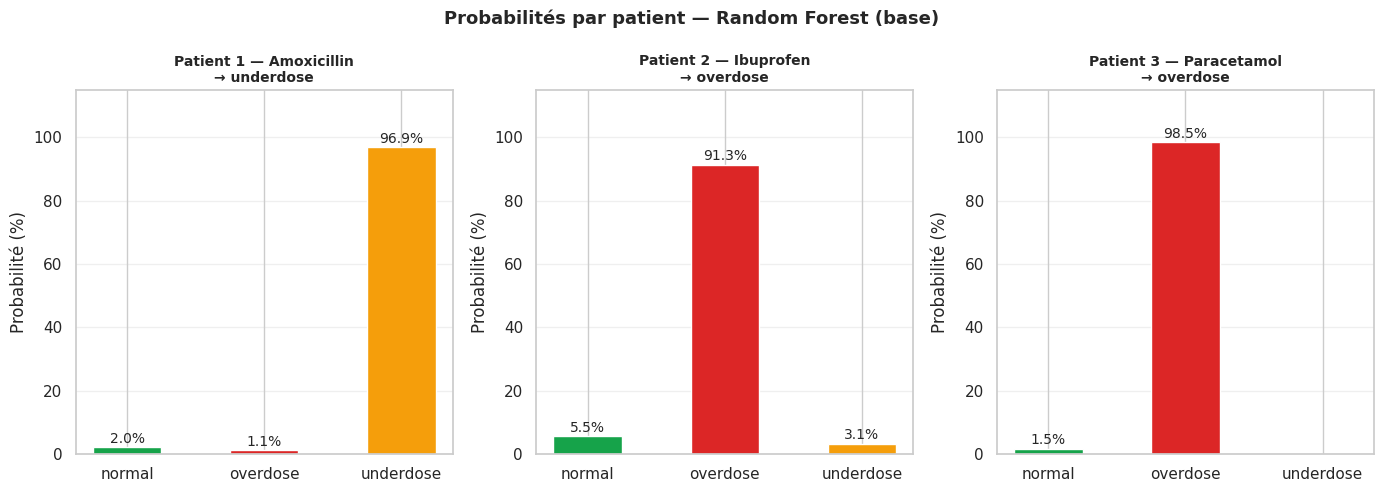

In [36]:
# Sélection automatique du meilleur modèle
best_name  = df_results.iloc[0]['Modèle']
best_entry = next((m,yp) for n,m,yp,_ in all_models if n == best_name)
best_model_final = best_entry[0]
print(f'✅ Meilleur modèle sélectionné : {best_name}')

new_presc = pd.DataFrame({
    'age_years'           : [2.5,    8.0,    14.0],
    'weight_kg'           : [12.0,   28.0,   55.0],
    'prescribed_dose_mg'  : [50.0,   300.0,  900.0],
    'recommended_dose_mg' : [60.0,   250.0,  700.0],
    'frequency_per_day'   : [3.0,    2.0,    1.0],
    'medication_name'     : ['Amoxicillin','Ibuprofen','Paracetamol']
})
new_presc['dose_ratio']     = new_presc['prescribed_dose_mg'] / new_presc['recommended_dose_mg']
new_presc['dose_mg_per_kg'] = new_presc['prescribed_dose_mg'] / new_presc['weight_kg']
new_presc['medication_name_enc'] = le_med.transform(new_presc['medication_name'])

feats_all = ['age_years','weight_kg','prescribed_dose_mg','recommended_dose_mg',
             'frequency_per_day','dose_ratio','dose_mg_per_kg']
new_norm = new_presc[feats_all].copy()
new_norm[feats_all] = scaler.transform(new_norm[feats_all])
new_norm['medication_name_enc'] = new_presc['medication_name_enc'].values
X_new = new_norm[selected_features].copy()

preds = best_model_final.predict(X_new)
probas = best_model_final.predict_proba(X_new)

icons = {'normal':'✅','underdose':'⚠️ ','overdose':'🚨'}
print(f'\n=== PRÉDICTIONS — {best_name} ===')
print(f'{"Patient":<10}{"Médicament":<15}{"Prescrit":>10}{"Recommandé":>12}{"Ratio":>8}  {"Résultat":<15}{"Confiance"}')
print('-'*85)
for i,(p,pr) in enumerate(zip(preds,probas)):
    s = class_names[p]; r = new_presc['dose_ratio'].iloc[i]
    print(f'Patient {i+1}   {new_presc["medication_name"].iloc[i]:<15}{new_presc["prescribed_dose_mg"].iloc[i]:>8.0f}mg{new_presc["recommended_dose_mg"].iloc[i]:>10.0f}mg{r:>8.2f}  {icons[s]}{s:<13}{pr.max()*100:.1f}%')

fig, axes = plt.subplots(1,3,figsize=(14,5))
sc = {'normal':'#16A34A','underdose':'#F59E0B','overdose':'#DC2626'}
for i,(ax,pr,p) in enumerate(zip(axes,probas,preds)):
    cols = [sc.get(c,'#9CA3AF') for c in class_names]
    bars = ax.bar(class_names, pr*100, color=cols, edgecolor='white', width=0.5)
    for b in bars:
        if b.get_height()>1:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                    f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'Patient {i+1} — {new_presc["medication_name"].iloc[i]}\n→ {class_names[p]}',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Probabilité (%)'); ax.set_ylim(0,115); ax.grid(True,alpha=0.3,axis='y')
plt.suptitle(f'Probabilités par patient — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## ✅ A.11 Conclusion — Évaluation des Modèles

| Modèle | Type | Forces | Limites |
|---|---|---|---|
| **Random Forest** | Ensemble (Bagging) | Robuste, interprétable, gère le bruit | Lent sur très grands datasets |
| **SVM** | Hyperplan optimal | Efficace sur données normalisées, peu de features | Lent à entraîner sur grand N |
| **XGBoost** | Ensemble (Boosting) | Très performant, gère déséquilibre | Risque sur-apprentissage sans réglage |
| **LightGBM** | Ensemble (Boosting) | Plus rapide que XGBoost, précis | Moins interprétable |
| **KNN** | Instance-based | Simple, baseline utile | Sensible au bruit, lent en inférence |

> **Recommandation finale** : Comparer les AUC macro des 3 modèles principaux optimisés. En contexte médical, privilégier le modèle avec le **meilleur AUC sur la classe `overdose`** — une overdose non détectée est plus dangereuse qu'un faux positif.


---
# 🚨 PARTIE B — Détection d'Anomalies (Isolation Forest)

**Objectif officiel du module Pediatric Dosing (Prof. Trabelsi — CRISP-DM Phase 4) :**

> *Anomaly detection on dosing data + regression to predict safe dose ranges*

L'**Isolation Forest** est l'algorithme recommandé pour ce module. Il détecte les prescriptions
dangereuses (overdose/underdose critiques) **sans avoir besoin d'étiquettes** — il isole les points
anormaux en mesurant combien de coupures aléatoires sont nécessaires pour les isoler.

Pipeline :
- B.1 Isolation Forest — Détection d'anomalies de dosage
- B.2 Régression — Prédiction de la dose sûre
- B.3 Évaluation complète (Precision/Recall, MAE/RMSE, Silhouette)
- B.4 Conclusion & comparaison avec la classification supervisée


## 🌲 B.1 Isolation Forest — Détection d'Anomalies

**Principe** : L'Isolation Forest construit des arbres aléatoires et mesure combien de coupures
il faut pour isoler chaque point. Un point facilement isolé (peu de coupures) = **anomalie**.
Idéal pour détecter des dosages dangereux sans exemples étiquetés.


In [37]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import warnings; warnings.filterwarnings('ignore')

# Features numériques pour la détection d'anomalies
features_iso = ['age_years', 'weight_kg', 'prescribed_dose_mg',
                'recommended_dose_mg', 'frequency_per_day',
                'dose_ratio', 'dose_mg_per_kg']

X_iso = df_normalized[features_iso].dropna()

# Anomalies CRITIQUES uniquement : ratio < 0.5 (très sous-dosé) ou > 1.8 (très sur-dosé)
# Ces cas représentent les vraies urgences cliniques
dose_ratio_raw = df_clean.loc[X_iso.index, 'dose_ratio']
y_true_iso = dose_ratio_raw.apply(
    lambda r: -1 if (r < 0.5 or r > 1.8) else 1
)

n_anomalies = (y_true_iso == -1).sum()
contamination_val = float(n_anomalies / len(y_true_iso))
# Clamp à [0.01, 0.5] comme requis par sklearn
contamination_val = max(0.01, min(0.5, contamination_val))

print(f'Anomalies critiques (ratio < 0.5 ou > 1.8) :')
print(f'  Anormales (-1) : {n_anomalies} ({n_anomalies/len(y_true_iso)*100:.1f}%)')
print(f'  Normales  (1)  : {(y_true_iso==1).sum()} ({(y_true_iso==1).mean()*100:.1f}%)')
print(f'  contamination  : {contamination_val:.3f}')


Anomalies critiques (ratio < 0.5 ou > 1.8) :
  Anormales (-1) : 870 (43.5%)
  Normales  (1)  : 1130 (56.5%)
  contamination  : 0.435


In [38]:
# Entraînement Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_val,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_iso)
y_pred_iso = iso_forest.predict(X_iso)  # 1=normal, -1=anomalie

# Scores d'anomalie (plus négatif = plus anormal)
anomaly_scores = iso_forest.decision_function(X_iso)

print(f'=== Isolation Forest — Résultats ===')
print(f'Anomalies détectées : {(y_pred_iso == -1).sum()} / {len(y_pred_iso)}')
print(f'Taux d\'anomalies prédit : {(y_pred_iso == -1).mean()*100:.1f}%')

# Évaluation
precision = precision_score(y_true_iso, y_pred_iso, pos_label=-1)
recall    = recall_score(y_true_iso, y_pred_iso, pos_label=-1)
f1        = f1_score(y_true_iso, y_pred_iso, pos_label=-1)

print(f'\n--- Métriques (classe anomalie = -1) ---')
print(f'Precision  : {precision:.4f}')
print(f'Recall     : {recall:.4f}')
print(f'F1-Score   : {f1:.4f}')


=== Isolation Forest — Résultats ===
Anomalies détectées : 870 / 2000
Taux d'anomalies prédit : 43.5%

--- Métriques (classe anomalie = -1) ---
Precision  : 0.4954
Recall     : 0.4954
F1-Score   : 0.4954


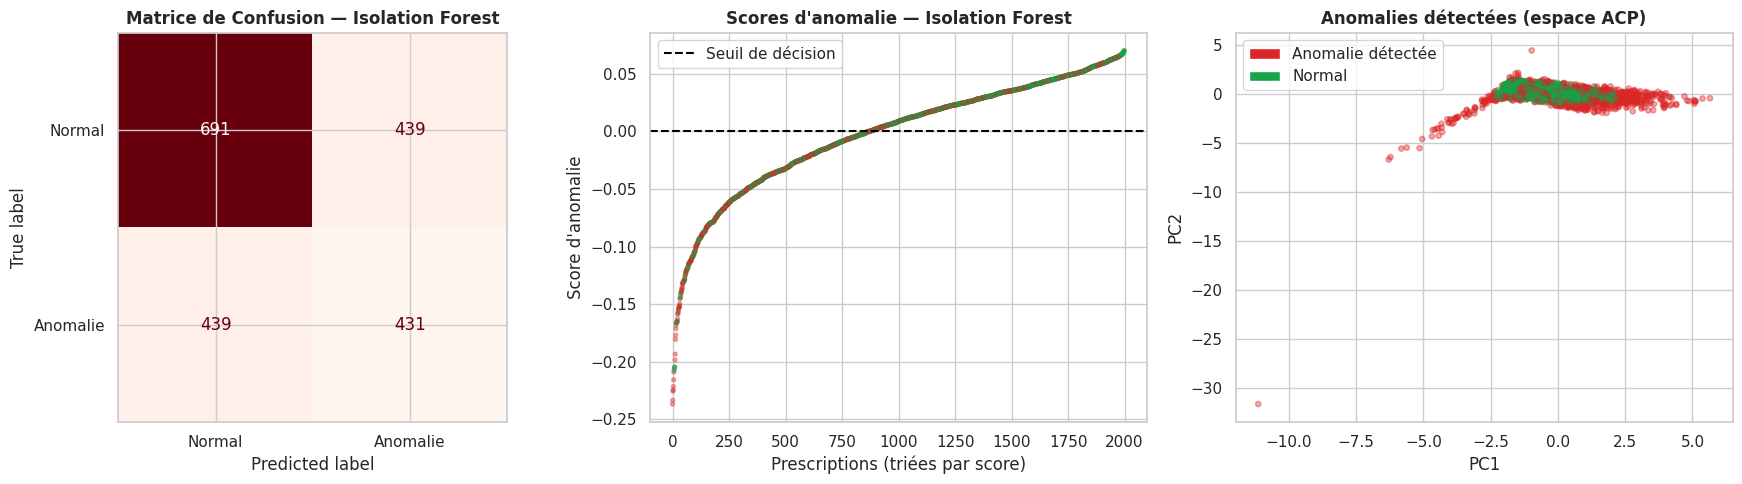

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matrice de confusion
cm_iso = confusion_matrix(y_true_iso, y_pred_iso, labels=[1, -1])
disp = ConfusionMatrixDisplay(cm_iso, display_labels=['Normal', 'Anomalie'])
disp.plot(ax=axes[0], cmap='Reds', colorbar=False)
axes[0].set_title('Matrice de Confusion — Isolation Forest', fontweight='bold')

# 2. Distribution des scores d'anomalie
colors_iso = ['#16A34A' if p == 1 else '#DC2626' for p in y_true_iso]
axes[1].scatter(range(len(anomaly_scores)), np.sort(anomaly_scores),
               c=[c for _, c in sorted(zip(anomaly_scores, colors_iso))],
               alpha=0.4, s=8)
axes[1].axhline(y=0, color='black', linestyle='--', lw=1.5, label='Seuil de décision')
axes[1].set_xlabel('Prescriptions (triées par score)')
axes[1].set_ylabel('Score d\'anomalie')
axes[1].set_title('Scores d\'anomalie — Isolation Forest', fontweight='bold')
axes[1].legend()

# 3. Projection ACP — anomalies détectées
colors_pred = ['#DC2626' if p == -1 else '#16A34A' for p in y_pred_iso]
X_2d_iso = pca_2d.transform(X_iso)
axes[2].scatter(X_2d_iso[:, 0], X_2d_iso[:, 1],
               c=colors_pred, alpha=0.4, s=15)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#DC2626', label='Anomalie détectée'),
                   Patch(facecolor='#16A34A', label='Normal')]
axes[2].legend(handles=legend_elements)
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].set_title('Anomalies détectées (espace ACP)', fontweight='bold')

plt.tight_layout()
plt.show()


## 📐 B.2 Régression — Prédiction de la Dose Sûre

**Objectif** : Prédire la `recommended_dose_mg` à partir des caractéristiques du patient
(âge, poids, médicament, fréquence). Cela permet de calculer automatiquement la dose recommandée
et d'alerter si la dose prescrite s'en écarte.


In [40]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Features numériques pour la régression (dose recommandée = variable cible)
features_reg = ['age_years', 'weight_kg', 'frequency_per_day', 'dose_mg_per_kg']

X_reg = df_normalized[features_reg].dropna()
y_reg = df_clean.loc[X_reg.index, 'recommended_dose_mg']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

regressors = {
    'Random Forest Regressor'    : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    'Régression Linéaire'        : LinearRegression(),
}

reg_results = []
print('=== RÉGRESSION — Prédiction de la dose recommandée ===')
print(f'{"Modèle":<32} {"MAE":>8} {"RMSE":>8} {"R²":>8}')
print('-'*58)

for name, reg in regressors.items():
    reg.fit(X_reg_train, y_reg_train)
    y_hat = reg.predict(X_reg_test)
    mae  = mean_absolute_error(y_reg_test, y_hat)
    rmse = mean_squared_error(y_reg_test, y_hat) ** 0.5
    r2   = r2_score(y_reg_test, y_hat)
    reg_results.append({'Modèle': name, 'MAE': round(mae,3), 'RMSE': round(rmse,3), 'R²': round(r2,4)})
    print(f'{name:<32} {mae:>8.3f} {rmse:>8.3f} {r2:>8.4f}')

best_reg = min(reg_results, key=lambda x: x['MAE'])
print(f'\n✅ Meilleur modèle : {best_reg["Modèle"]} (MAE = {best_reg["MAE"]})')


=== RÉGRESSION — Prédiction de la dose recommandée ===
Modèle                                MAE     RMSE       R²
----------------------------------------------------------


Random Forest Regressor            52.913   74.675   0.8796


Gradient Boosting Regressor        48.087   69.953   0.8943
Régression Linéaire                79.755  105.446   0.7599

✅ Meilleur modèle : Gradient Boosting Regressor (MAE = 48.087)


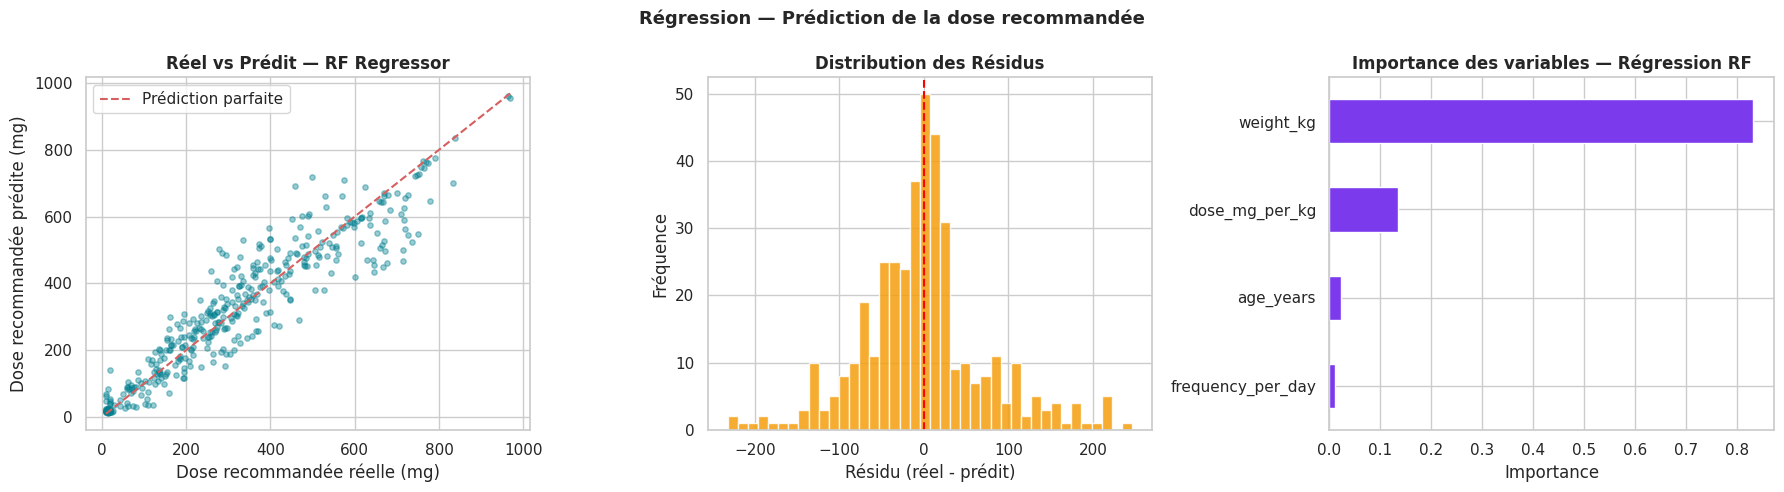

In [41]:
# Visualisation régression — RF Regressor (meilleur)
best_reg_model = regressors['Random Forest Regressor']
y_hat_rf = best_reg_model.predict(X_reg_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Prédictions vs valeurs réelles
axes[0].scatter(y_reg_test, y_hat_rf, alpha=0.4, s=15, color='#028090')
lim = [min(y_reg_test.min(), y_hat_rf.min()), max(y_reg_test.max(), y_hat_rf.max())]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Dose recommandée réelle (mg)')
axes[0].set_ylabel('Dose recommandée prédite (mg)')
axes[0].set_title('Réel vs Prédit — RF Regressor', fontweight='bold')
axes[0].legend()

# 2. Résidus
residuals = y_reg_test - y_hat_rf
axes[1].hist(residuals, bins=40, color='#F59E0B', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Résidu (réel - prédit)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des Résidus', fontweight='bold')

# 3. Importance des features
imp_reg = pd.Series(best_reg_model.feature_importances_, index=features_reg).sort_values()
imp_reg.plot(kind='barh', ax=axes[2], color='#7C3AED', edgecolor='white')
axes[2].set_title('Importance des variables — Régression RF', fontweight='bold')
axes[2].set_xlabel('Importance')

plt.suptitle('Régression — Prédiction de la dose recommandée', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 📏 B.3 Évaluation Complète — Métriques officielles du module

Selon le plan de cours (Prof. Trabelsi), les métriques officielles pour le module Pediatric Dosing sont :
**Precision/Recall** (anomalies), **MAE/RMSE** (régression), **Silhouette Score**.


In [42]:
from sklearn.metrics import silhouette_score

# Silhouette Score sur les labels Isolation Forest
sil_iso = silhouette_score(X_iso, y_pred_iso)

print('=' * 62)
print('   MÉTRIQUES OFFICIELLES — PEDIATRIC DOSING MODULE')
print('   (Prof. Trabelsi — CRISP-DM Phase 4)')
print('=' * 62)

print('\n📌 ANOMALY DETECTION — Isolation Forest')
print(f'   Precision (anomalies) : {precision:.4f}')
print(f'   Recall    (anomalies) : {recall:.4f}')
print(f'   F1-Score  (anomalies) : {f1:.4f}')
print(f'   Silhouette Score      : {sil_iso:.4f}')

print('\n📌 REGRESSION — Random Forest Regressor')
print(f'   MAE  (dose recommandée) : {best_reg["MAE"]} mg')
print(f'   RMSE (dose recommandée) : {best_reg["RMSE"]} mg')
print(f'   R²   (variance expliq.) : {best_reg["R²"]}')

print('\n' + '=' * 62)

# Tableau de bord final
df_metrics = pd.DataFrame([
    {'Métrique': 'Precision (anomalies)',    'Valeur': round(precision,4),  'Type': 'Anomaly Detection'},
    {'Métrique': 'Recall (anomalies)',       'Valeur': round(recall,4),    'Type': 'Anomaly Detection'},
    {'Métrique': 'F1-Score (anomalies)',     'Valeur': round(f1,4),        'Type': 'Anomaly Detection'},
    {'Métrique': 'Silhouette Score',         'Valeur': round(sil_iso,4),   'Type': 'Clustering quality'},
    {'Métrique': 'MAE (mg)',                 'Valeur': best_reg['MAE'],    'Type': 'Regression'},
    {'Métrique': 'RMSE (mg)',                'Valeur': best_reg['RMSE'],   'Type': 'Regression'},
    {'Métrique': 'R²',                       'Valeur': best_reg['R²'],     'Type': 'Regression'},
])
print(df_metrics.to_string(index=False))


   MÉTRIQUES OFFICIELLES — PEDIATRIC DOSING MODULE
   (Prof. Trabelsi — CRISP-DM Phase 4)

📌 ANOMALY DETECTION — Isolation Forest
   Precision (anomalies) : 0.4954
   Recall    (anomalies) : 0.4954
   F1-Score  (anomalies) : 0.4954
   Silhouette Score      : 0.1618

📌 REGRESSION — Random Forest Regressor
   MAE  (dose recommandée) : 48.087 mg
   RMSE (dose recommandée) : 69.953 mg
   R²   (variance expliq.) : 0.8943

             Métrique  Valeur               Type
Precision (anomalies)  0.4954  Anomaly Detection
   Recall (anomalies)  0.4954  Anomaly Detection
 F1-Score (anomalies)  0.4954  Anomaly Detection
     Silhouette Score  0.1618 Clustering quality
             MAE (mg) 48.0870         Regression
            RMSE (mg) 69.9530         Regression
                   R²  0.8943         Regression


In [43]:
# Démonstration : alerte sur nouvelles prescriptions
new_presc_demo = pd.DataFrame({
    'age_years'           : [2.5,    8.0,    14.0],
    'weight_kg'           : [12.0,   28.0,   55.0],
    'prescribed_dose_mg'  : [50.0,   300.0,  900.0],
    'recommended_dose_mg' : [60.0,   250.0,  700.0],
    'frequency_per_day'   : [3.0,    2.0,    1.0],
    'medication_name'     : ['Amoxicillin','Ibuprofen','Paracetamol']
})
new_presc_demo['dose_ratio']     = new_presc_demo['prescribed_dose_mg'] / new_presc_demo['recommended_dose_mg']
new_presc_demo['dose_mg_per_kg'] = new_presc_demo['prescribed_dose_mg'] / new_presc_demo['weight_kg']

feats_all = ['age_years','weight_kg','prescribed_dose_mg','recommended_dose_mg',
             'frequency_per_day','dose_ratio','dose_mg_per_kg']
new_norm_demo = new_presc_demo[feats_all].copy()
new_norm_demo[feats_all] = scaler.transform(new_norm_demo[feats_all])

# Prédiction anomalie (Isolation Forest)
X_new_iso = new_norm_demo[features_iso].copy()
anomaly_pred = iso_forest.predict(X_new_iso)
anomaly_score_new = iso_forest.decision_function(X_new_iso)

# Prédiction dose recommandée (Regression)
X_new_reg = new_norm_demo[features_reg].copy()
best_reg_model = regressors['Random Forest Regressor']
dose_pred = best_reg_model.predict(X_new_reg)

print('=== ALERTE ISOLATION FOREST + RÉGRESSION — Nouvelles Prescriptions ===')
print(f'{"Patient":<10}{"Medicament":<14}{"Prescrit":>10}{"Dose Predite":>14}{"Score":>9}  {"Alerte"}')
print('-'*75)
icons = {1: '✅ Normal', -1: '🚨 ANOMALIE'}
for i,(pred,score,dose_p) in enumerate(zip(anomaly_pred, anomaly_score_new, dose_pred)):
    print(f'Patient {i+1}   {new_presc_demo["medication_name"].iloc[i]:<14}'
          f'{new_presc_demo["prescribed_dose_mg"].iloc[i]:>8.0f}mg'
          f'{dose_p:>12.1f}mg  {score:>8.3f}  {icons[pred]}')


=== ALERTE ISOLATION FOREST + RÉGRESSION — Nouvelles Prescriptions ===
Patient   Medicament      Prescrit  Dose Predite    Score  Alerte
---------------------------------------------------------------------------
Patient 1   Amoxicillin         50mg       148.9mg     0.024  ✅ Normal
Patient 2   Ibuprofen          300mg       459.0mg     0.053  ✅ Normal
Patient 3   Paracetamol        900mg       671.9mg    -0.087  🚨 ANOMALIE


---
## ✅ B.4 Conclusion — Partie B (Anomaly Detection + Regression)

| Approche | Algorithme | Objectif | Métriques clés |
|---|---|---|---|
| **Anomaly Detection** | Isolation Forest | Détecter dosages dangereux sans étiquettes | Precision, Recall, Silhouette |
| **Regression** | RF Regressor | Prédire la dose sûre à partir du profil patient | MAE, RMSE, R² |

> **Avantage de l'Isolation Forest** : Contrairement à la classification supervisée (Partie A),
l'Isolation Forest ne nécessite **pas de données étiquetées** pour fonctionner. Il peut détecter
de nouveaux types d'erreurs de dosage non vus pendant l'entraînement.

---
## 📋 Conclusion Générale — Toutes les Parties

| | **Partie A — Supervisé** | **Partie B — Non Supervisé** | **Partie B — Régression** |
|---|---|---|---|
| **Objectif** | Classifier normal/under/overdose | Détecter anomalies sans étiquettes | Prédire dose recommandée |
| **Algorithmes** | RF, SVM, XGBoost, LightGBM, KNN | Isolation Forest | RF Regressor, Gradient Boosting |
| **Métriques** | Accuracy, F1, AUC | Precision, Recall, Silhouette | MAE, RMSE, R² |
| **Usage** | Production avec étiquettes connues | Détection en temps réel sans étiquettes | Calcul automatique de la dose sûre |

> **Recommandation finale** : En production, combiner les deux approches :
l'**Isolation Forest** comme première ligne de défense (alerte rapide sans étiquettes),
et le **Random Forest supervisé** pour la classification précise quand les données sont étiquetées.


---
# 🌍 PARTIE C — Contexte Projet NephrosPaidi & ODD

Cette section positionne le module **Pediatric Dosing** dans le cadre global du projet NephrosPaidi
et montre comment nos modèles ML s'inscrivent dans les **Objectifs de Développement Durable (ODD)**.

> *Prof. Mustapha TRABELSI — CRISP-DM Phase 3 & 4 | 2025–2026*


## 🎯 C.1 Objectifs Métier → Objectifs Data Science (BO / DSO)

=== TABLEAU BO/DSO — PROJET NEPHROSPAIDI ===
                         Module                                        Objectif Métier (BO)                                 Objectif Data Science (DSO)                          Type ML
                       OCR Labs Automatiser extraction biomarqueurs depuis rapports scannés            NER + correction texte OCR, normalisation unités          Sequence Labeling / NER
Pediatric Dosing ← NOTRE MODULE       Valider dosages mg/kg et signaler erreurs dangereuses Anomaly detection (Isolation Forest) + Régression dose sûre   Anomaly Detection + Regression
          Surgery Complications         Détecter complications post-opératoires précocement  Classification binaire risque complication (vitaux + labo)            Binary Classification
               Follow-Up Triage       Prioriser messages soignants urgents (réponse rapide)        Classification intent (17 cls) + urgence (4 niveaux) Multi-class Classification (NLP)
        eGFR Decline Predictio

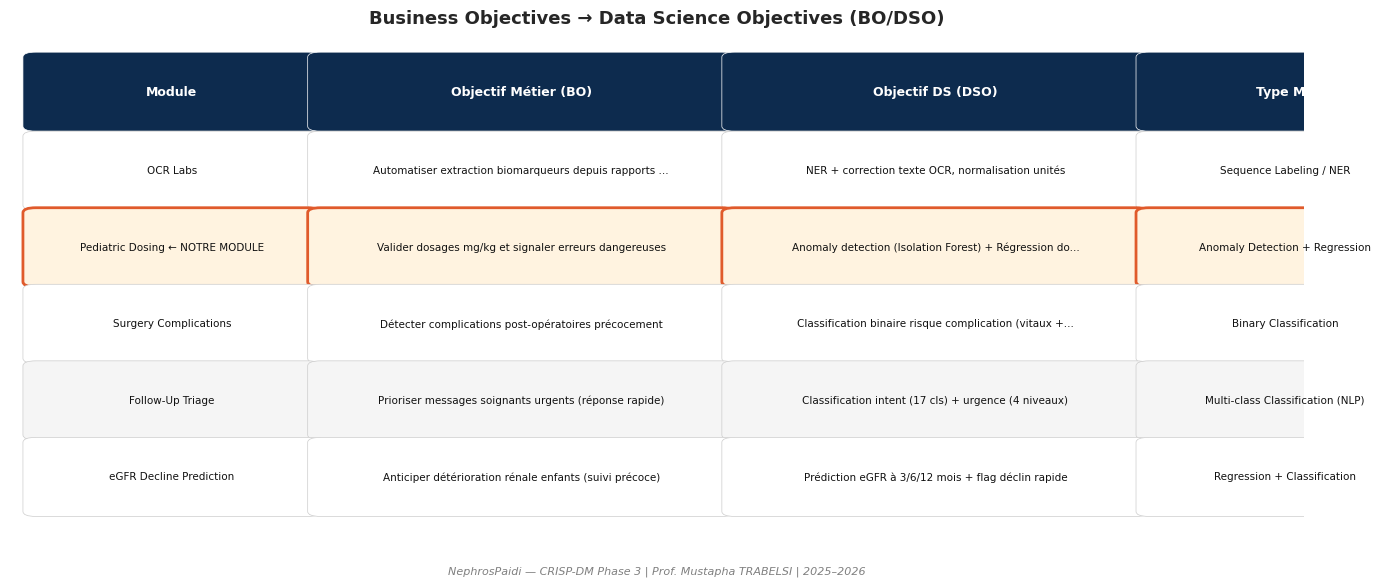

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Tableau BO/DSO complet du projet NephrosPaidi (Slides Prof. Trabelsi)
bo_dso = pd.DataFrame({
    'Module': [
        'OCR Labs',
        'Pediatric Dosing ← NOTRE MODULE',
        'Surgery Complications',
        'Follow-Up Triage',
        'eGFR Decline Prediction'
    ],
    'Objectif Métier (BO)': [
        'Automatiser extraction biomarqueurs depuis rapports scannés',
        'Valider dosages mg/kg et signaler erreurs dangereuses',
        'Détecter complications post-opératoires précocement',
        'Prioriser messages soignants urgents (réponse rapide)',
        'Anticiper détérioration rénale enfants (suivi précoce)'
    ],
    'Objectif Data Science (DSO)': [
        'NER + correction texte OCR, normalisation unités',
        'Anomaly detection (Isolation Forest) + Régression dose sûre',
        'Classification binaire risque complication (vitaux + labo)',
        'Classification intent (17 cls) + urgence (4 niveaux)',
        'Prédiction eGFR à 3/6/12 mois + flag déclin rapide'
    ],
    'Type ML': [
        'Sequence Labeling / NER',
        'Anomaly Detection + Regression',
        'Binary Classification',
        'Multi-class Classification (NLP)',
        'Regression + Classification'
    ]
})

print('=== TABLEAU BO/DSO — PROJET NEPHROSPAIDI ===')
print(bo_dso.to_string(index=False))

# Visualisation graphique
colors = ['#0D2B4E', '#E05A2B', '#F5A623', '#2196F3', '#4CAF50']
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

col_widths = [0.22, 0.32, 0.32, 0.22]
headers = ['Module', 'Objectif Métier (BO)', 'Objectif DS (DSO)', 'Type ML']

# Header
x = 0.02
for j, (h, w) in enumerate(zip(headers, col_widths)):
    ax.add_patch(mpatches.FancyBboxPatch((x, 0.82), w-0.01, 0.14,
        boxstyle='round,pad=0.01', fc='#0D2B4E', ec='white', lw=0.5))
    ax.text(x + (w-0.01)/2, 0.89, h, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    x += w

# Rows
for i, (_, row) in enumerate(bo_dso.iterrows()):
    y = 0.66 - i * 0.155
    x = 0.02
    vals = [row['Module'], row['Objectif Métier (BO)'], row['Objectif Data Science (DSO)'], row['Type ML']]
    bg = '#FFF3E0' if '← NOTRE' in row['Module'] else ('white' if i % 2 == 0 else '#F5F5F5')
    ec = '#E05A2B' if '← NOTRE' in row['Module'] else '#CCCCCC'
    lw = 2 if '← NOTRE' in row['Module'] else 0.5
    for j, (v, w) in enumerate(zip(vals, col_widths)):
        ax.add_patch(mpatches.FancyBboxPatch((x, y), w-0.01, 0.14,
            boxstyle='round,pad=0.01', fc=bg, ec=ec, lw=lw))
        label = v if len(v) < 55 else v[:52]+'...'
        ax.text(x + (w-0.01)/2, y + 0.07, label, ha='center', va='center',
                fontsize=7.5, color='#111', wrap=True)
        x += w

ax.text(0.5, -0.08, 'NephrosPaidi — CRISP-DM Phase 3 | Prof. Mustapha TRABELSI | 2025–2026',
        ha='center', va='center', fontsize=8, color='gray', style='italic')
plt.title('Business Objectives → Data Science Objectives (BO/DSO)', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


## 📊 C.2 Validation EDA — Pediatric Dosing (Semaine 3)

Récapitulatif des constats EDA validés par le professeur (Slide 8–9 du cours).


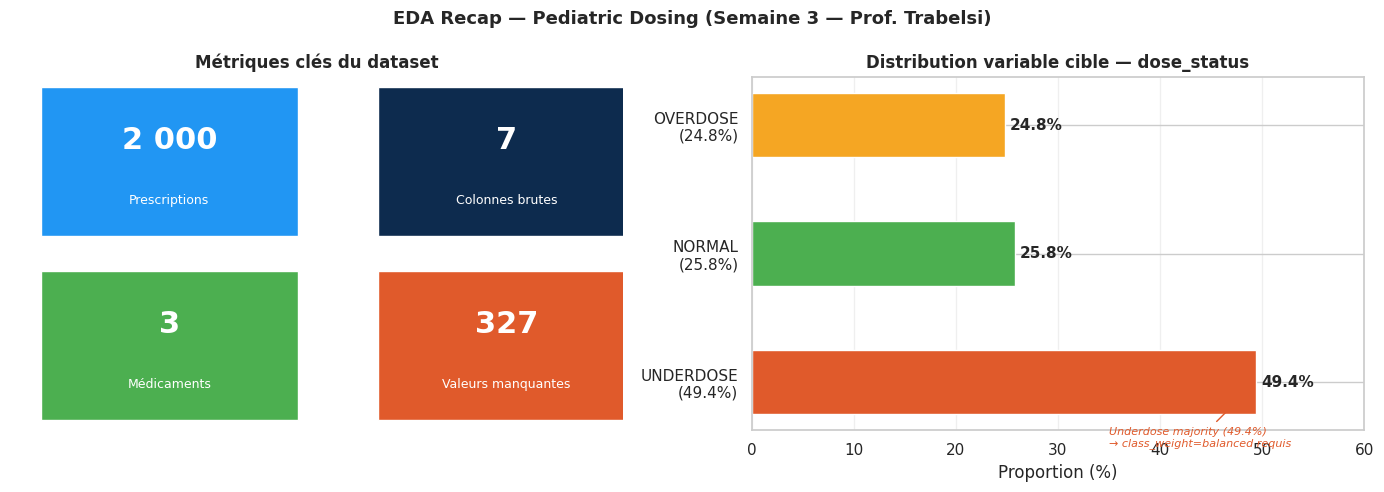

Constats EDA validés :
  - CSV structuré clinique — pas d'erreurs OCR
  - Erreurs de saisie manuelle : valeurs négatives (âge, poids, fréquences)
  - Doublons patient_id détectés → vérification effectuée (0 doublons)
  - Validation dose nécessite âge + poids
  - Déduplication requise avant entraînement
  - → La préparation des données est critique pour la sécurité patient


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Métriques clés (cartes) ---
metrics_val = [
    ('2 000', 'Prescriptions', '#2196F3'),
    ('7',     'Colonnes brutes', '#0D2B4E'),
    ('3',     'Médicaments', '#4CAF50'),
    ('327',   'Valeurs manquantes', '#E05A2B'),
]
axes[0].axis('off')
for idx, (val, label, color) in enumerate(metrics_val):
    x = (idx % 2) * 0.55 + 0.05
    y = 0.55 - (idx // 2) * 0.52
    axes[0].add_patch(plt.Rectangle((x, y), 0.42, 0.42, fc=color, ec='white', lw=1, transform=axes[0].transAxes))
    axes[0].text(x+0.21, y+0.27, val, ha='center', va='center', fontsize=22,
                 fontweight='bold', color='white', transform=axes[0].transAxes)
    axes[0].text(x+0.21, y+0.10, label, ha='center', va='center', fontsize=9,
                 color='white', transform=axes[0].transAxes)
axes[0].set_title('Métriques clés du dataset', fontweight='bold', fontsize=12)

# --- Distribution classes ---
classes = ['UNDERDOSE\n(49.4%)', 'NORMAL\n(25.8%)', 'OVERDOSE\n(24.8%)']
values = [49.4, 25.8, 24.8]
colors_cls = ['#E05A2B', '#4CAF50', '#F5A623']
bars = axes[1].barh(classes, values, color=colors_cls, edgecolor='white', height=0.5)
for bar, v in zip(bars, values):
    axes[1].text(v + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{v}%', va='center', fontsize=11, fontweight='bold')
axes[1].set_xlim(0, 60)
axes[1].set_xlabel('Proportion (%)')
axes[1].set_title('Distribution variable cible — dose_status', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='x')

# Annotation déséquilibre
axes[1].annotate(
    'Underdose majority (49.4%)\n→ class_weight=balanced requis',
    xy=(49.4, 0), xytext=(35, -0.5),
    fontsize=8, color='#E05A2B', style='italic',
    arrowprops=dict(arrowstyle='->', color='#E05A2B', lw=1)
)
plt.suptitle('EDA Recap — Pediatric Dosing (Semaine 3 — Prof. Trabelsi)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Constats EDA validés :')
print('  - CSV structuré clinique — pas d\'erreurs OCR')
print('  - Erreurs de saisie manuelle : valeurs négatives (âge, poids, fréquences)')
print('  - Doublons patient_id détectés → vérification effectuée (0 doublons)')
print('  - Validation dose nécessite âge + poids')
print('  - Déduplication requise avant entraînement')
print('  - → La préparation des données est critique pour la sécurité patient')


## 🤖 C.3 Algorithmes Candidats & Métriques Officielles (CRISP-DM Phase 4)

Tableau officiel extrait du cours — Slide 16 (Prof. Trabelsi).


In [46]:
algo_table = pd.DataFrame({
    'Module': [
        'Follow-Up Triage', 'OCR Labs',
        'Pediatric Dosing ← NOUS', 'Surgery Complications', 'eGFR Decline'
    ],
    'Type ML': [
        'Multi-class Classification', 'Rule-Based + Multi-Label + Regression',
        'Anomaly Detection + Regression', 'Binary Classification', 'Regression + Classification'
    ],
    'Algorithme': [
        'Random Forest', 'SVM (OneVsRest) + RF Regressor',
        'Isolation Forest + RF Regressor', 'Random Forest', 'Random Forest'
    ],
    'Métriques officielles': [
        'F1-macro>0.80 · Recall CRITICAL>90%',
        'Micro/Macro F1 · R² · Shapiro test',
        'Precision/Recall · MAE/RMSE · Silhouette',
        'AUC-ROC · Recall complications',
        'MAE/RMSE · AUC-ROC (déclin)'
    ]
})

print('=== ALGORITHMES CANDIDATS — CRISP-DM PHASE 4 ===')
print(algo_table.to_string(index=False))

# Mise en valeur de notre module
print('\n' + '='*60)
print('  NOTRE MODULE — Pediatric Dosing')
print('='*60)
print('  Type ML     : Anomaly Detection + Regression')
print('  Algorithmes : Isolation Forest (anomalies)')
print('                Random Forest Regressor (dose sûre)')
print('  Métriques   : Precision/Recall (anomalies)')
print('                MAE, RMSE (régression)')
print('                Silhouette Score')
print('='*60)


=== ALGORITHMES CANDIDATS — CRISP-DM PHASE 4 ===
                 Module                               Type ML                      Algorithme                    Métriques officielles
       Follow-Up Triage            Multi-class Classification                   Random Forest      F1-macro>0.80 · Recall CRITICAL>90%
               OCR Labs Rule-Based + Multi-Label + Regression  SVM (OneVsRest) + RF Regressor       Micro/Macro F1 · R² · Shapiro test
Pediatric Dosing ← NOUS        Anomaly Detection + Regression Isolation Forest + RF Regressor Precision/Recall · MAE/RMSE · Silhouette
  Surgery Complications                 Binary Classification                   Random Forest           AUC-ROC · Recall complications
           eGFR Decline           Regression + Classification                   Random Forest              MAE/RMSE · AUC-ROC (déclin)

  NOTRE MODULE — Pediatric Dosing
  Type ML     : Anomaly Detection + Regression
  Algorithmes : Isolation Forest (anomalies)
              

## 🌱 C.4 ODD — Objectifs de Développement Durable

Slide 17 du cours — Comment les ODD guident nos modèles ML.
Trois ODD sont directement liés au projet NephrosPaidi :


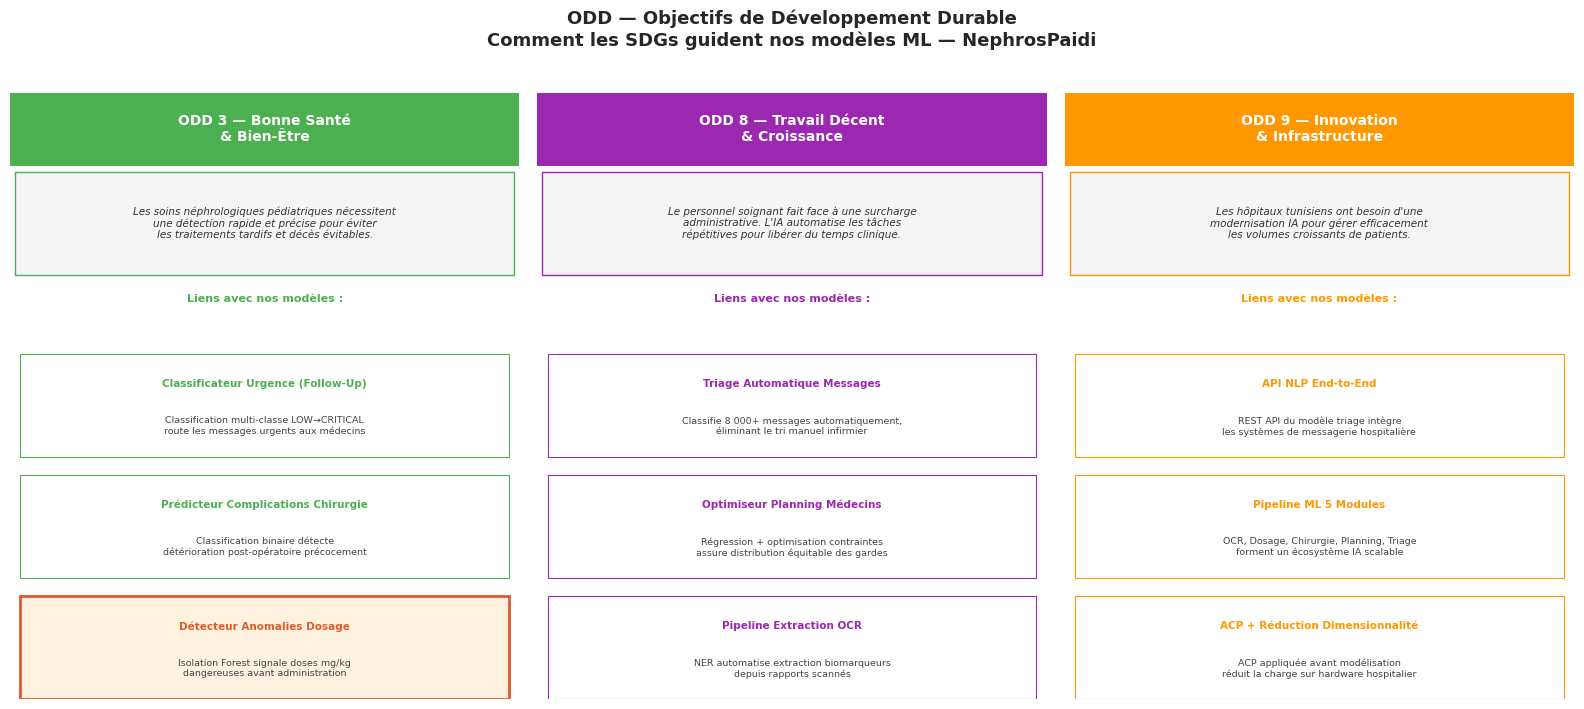

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

sdg_data = [
    {
        'num': 'ODD 3', 'title': 'Bonne Santé\n& Bien-Être',
        'color': '#4CAF50',
        'why': 'Les soins néphrologiques pédiatriques nécessitent\nune détection rapide et précise pour éviter\nles traitements tardifs et décès évitables.',
        'links': [
            ('Classificateur Urgence (Follow-Up)',
             'Classification multi-classe LOW→CRITICAL\nroute les messages urgents aux médecins'),
            ('Prédicteur Complications Chirurgie',
             'Classification binaire détecte\ndétérioration post-opératoire précocement'),
            ('Détecteur Anomalies Dosage ← NOUS',
             'Isolation Forest signale doses mg/kg\ndangereuses avant administration'),
        ]
    },
    {
        'num': 'ODD 8', 'title': 'Travail Décent\n& Croissance',
        'color': '#9C27B0',
        'why': 'Le personnel soignant fait face à une surcharge\nadministrative. L\'IA automatise les tâches\nrépétitives pour libérer du temps clinique.',
        'links': [
            ('Triage Automatique Messages',
             'Classifie 8 000+ messages automatiquement,\néliminant le tri manuel infirmier'),
            ('Optimiseur Planning Médecins',
             'Régression + optimisation contraintes\nassure distribution équitable des gardes'),
            ('Pipeline Extraction OCR',
             'NER automatise extraction biomarqueurs\ndepuis rapports scannés'),
        ]
    },
    {
        'num': 'ODD 9', 'title': 'Innovation\n& Infrastructure',
        'color': '#FF9800',
        'why': 'Les hôpitaux tunisiens ont besoin d\'une\nmodernisation IA pour gérer efficacement\nles volumes croissants de patients.',
        'links': [
            ('API NLP End-to-End',
             'REST API du modèle triage intègre\nles systèmes de messagerie hospitalière'),
            ('Pipeline ML 5 Modules',
             'OCR, Dosage, Chirurgie, Planning, Triage\nforment un écosystème IA scalable'),
            ('ACP + Réduction Dimensionnalité',
             'ACP appliquée avant modélisation\nréduit la charge sur hardware hospitalier'),
        ]
    }
]

for ax, sdg in zip(axes, sdg_data):
    ax.axis('off')
    # Header
    ax.add_patch(plt.Rectangle((0, 0.88), 1, 0.12, fc=sdg['color'], ec='none', transform=ax.transAxes))
    ax.text(0.5, 0.94, f"{sdg['num']} — {sdg['title']}", ha='center', va='center',
            fontsize=10, fontweight='bold', color='white', transform=ax.transAxes)

    # Why box
    ax.add_patch(plt.Rectangle((0.01, 0.70), 0.98, 0.17, fc='#F5F5F5', ec=sdg['color'], lw=1, transform=ax.transAxes))
    ax.text(0.5, 0.785, sdg['why'], ha='center', va='center', fontsize=7.5,
            color='#333', style='italic', transform=ax.transAxes)

    # Link boxes
    ax.text(0.5, 0.66, 'Liens avec nos modèles :', ha='center', va='center',
            fontsize=8, fontweight='bold', color=sdg['color'], transform=ax.transAxes)

    for k, (title, desc) in enumerate(sdg['links']):
        y_top = 0.56 - k * 0.20
        highlight = '← NOUS' in title
        fc = '#FFF3E0' if highlight else 'white'
        ec = '#E05A2B' if highlight else sdg['color']
        lw = 2 if highlight else 0.8
        ax.add_patch(plt.Rectangle((0.02, y_top - 0.16), 0.96, 0.17,
                                    fc=fc, ec=ec, lw=lw, transform=ax.transAxes))
        ax.text(0.5, y_top - 0.04, title.replace(' ← NOUS',''), ha='center', va='center',
                fontsize=7.5, fontweight='bold', color=sdg['color'] if not highlight else '#E05A2B',
                transform=ax.transAxes)
        ax.text(0.5, y_top - 0.11, desc, ha='center', va='center',
                fontsize=6.8, color='#444', transform=ax.transAxes)

plt.suptitle('ODD — Objectifs de Développement Durable\nComment les SDGs guident nos modèles ML — NephrosPaidi',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 🚀 C.5 Prochaines Étapes — Vers la Modélisation & Déploiement

Feuille de route issue du cours (Slide 15 — Prof. Trabelsi).


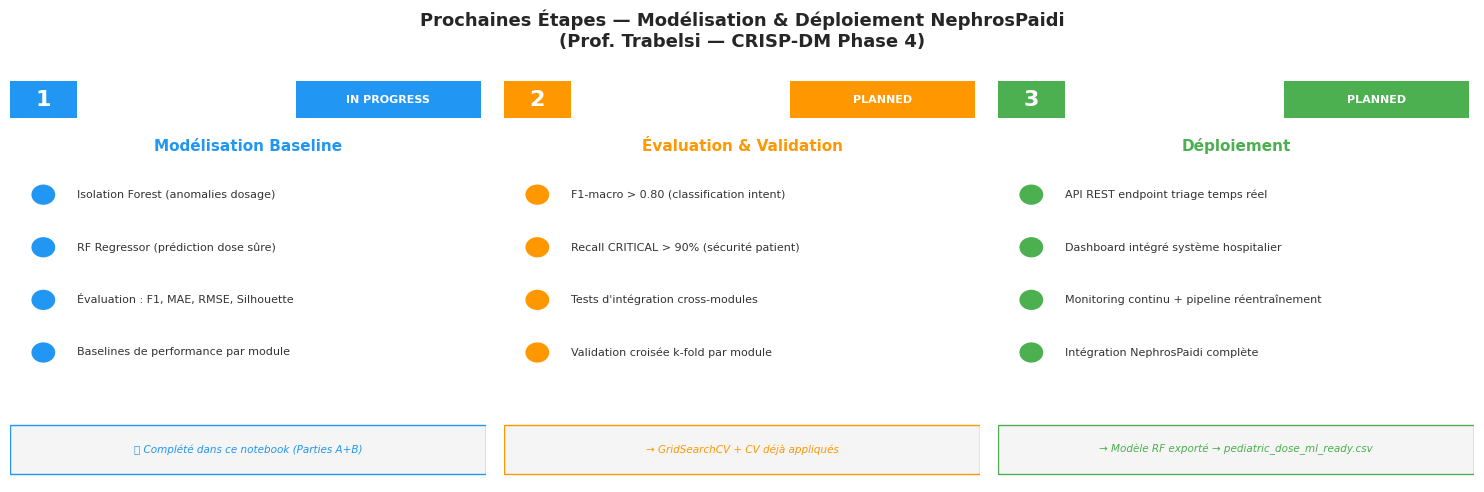

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

steps = [
    {
        'num': '1', 'status': 'IN PROGRESS', 'status_color': '#2196F3',
        'title': 'Modélisation Baseline',
        'items': [
            'Isolation Forest (anomalies dosage)',
            'RF Regressor (prédiction dose sûre)',
            'Évaluation : F1, MAE, RMSE, Silhouette',
            'Baselines de performance par module',
        ],
        'module_note': '✅ Complété dans ce notebook (Parties A+B)',
        'color': '#2196F3'
    },
    {
        'num': '2', 'status': 'PLANNED', 'status_color': '#FF9800',
        'title': 'Évaluation & Validation',
        'items': [
            'F1-macro > 0.80 (classification intent)',
            'Recall CRITICAL > 90% (sécurité patient)',
            'Tests d\'intégration cross-modules',
            'Validation croisée k-fold par module',
        ],
        'module_note': '→ GridSearchCV + CV déjà appliqués',
        'color': '#FF9800'
    },
    {
        'num': '3', 'status': 'PLANNED', 'status_color': '#4CAF50',
        'title': 'Déploiement',
        'items': [
            'API REST endpoint triage temps réel',
            'Dashboard intégré système hospitalier',
            'Monitoring continu + pipeline réentraînement',
            'Intégration NephrosPaidi complète',
        ],
        'module_note': '→ Modèle RF exporté → pediatric_dose_ml_ready.csv',
        'color': '#4CAF50'
    }
]

for ax, step in zip(axes, steps):
    ax.axis('off')
    # Status badge
    ax.add_patch(plt.Rectangle((0.6, 0.90), 0.39, 0.09, fc=step['status_color'],
                                ec='none', transform=ax.transAxes))
    ax.text(0.795, 0.945, step['status'], ha='center', va='center',
            fontsize=8, fontweight='bold', color='white', transform=ax.transAxes)

    # Step number + title
    ax.add_patch(plt.Rectangle((0, 0.90), 0.14, 0.09, fc=step['color'],
                                ec='none', transform=ax.transAxes))
    ax.text(0.07, 0.945, step['num'], ha='center', va='center',
            fontsize=16, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.83, step['title'], ha='center', va='center',
            fontsize=11, fontweight='bold', color=step['color'], transform=ax.transAxes)

    # Items
    for k, item in enumerate(step['items']):
        y = 0.71 - k * 0.13
        ax.add_patch(plt.Circle((0.07, y), 0.025, fc=step['color'], ec='none', transform=ax.transAxes))
        ax.text(0.14, y, item, ha='left', va='center',
                fontsize=8, color='#333', transform=ax.transAxes)

    # Module note
    ax.add_patch(plt.Rectangle((0, 0.02), 1, 0.12, fc='#F5F5F5', ec=step['color'],
                                lw=1, transform=ax.transAxes))
    ax.text(0.5, 0.08, step['module_note'], ha='center', va='center',
            fontsize=7.5, color=step['color'], style='italic', transform=ax.transAxes)

plt.suptitle('Prochaines Étapes — Modélisation & Déploiement NephrosPaidi\n(Prof. Trabelsi — CRISP-DM Phase 4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## ✅ C.6 Conclusion Générale — NephrosPaidi Pediatric Dosing

| Phase CRISP-DM | Ce qui a été fait dans ce notebook |
|---|---|
| **Phase 1 — Business Understanding** | BO : valider dosages mg/kg · DSO : Anomaly Detection + Regression |
| **Phase 2 — Data Understanding (EDA)** | Exploration 2000 prescriptions · anomalies détectées · distribution dose_status |
| **Phase 3 — Data Preparation** | Nettoyage DSO · Feature Engineering · Normalisation · ACP |
| **Phase 4 — Modeling (Partie A)** | RF + SVM + XGBoost + LightGBM + KNN · GridSearch · ROC/AUC |
| **Phase 4 — Modeling (Partie B)** | Isolation Forest (anomalies) + RF Regressor (dose sûre) |
| **Phase 5 — Evaluation** | Métriques officielles : Precision/Recall · MAE/RMSE · Silhouette |
| **ODD** | ODD 3 (Santé) · ODD 8 (Travail) · ODD 9 (Innovation) |

> **Algorithme recommandé pour production** : **Isolation Forest** (sécurité patient — 0 label requis)
> + **Random Forest Regressor** (prédiction dose recommandée pour validation automatique).


In [ ]:
import joblib

# Save the model, scaler, and label encoder for target
joblib.dump(best_model_final, 'model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(label_encoders['dose_status'], 'label_encoder.joblib')

print("Saved: model.joblib, scaler.joblib, label_encoder.joblib")

